## Introduction

**Retail vs. Institutional News: Which Makes Markets Move?**

**Research Question:** Does retail social-media sentiment (Reddit/WallStreetBets) or Institutional financial news provide greater explanatory or predictive information about GameStop (GME) market movements during the 2020-2021 meme-stock episode?

This notebook analyzes Reddit and news sentiment, topic structure, same-day market associations, next-day predictive performance, Granger relationships, and abnormal returns around major GME events.

In [2]:
# ---------------------------------------------------------
# Imports
# ---------------------------------------------------------
from pathlib import Path
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score)
from collections import Counter
from statsmodels.tsa.stattools import grangercausalitytests
from scipy.stats import norm, mannwhitneyu, ttest_ind, pearsonr, spearmanr
from contextlib import redirect_stdout

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import re
import io
import statsmodels.api as sm
import warnings

In [3]:
# ------------------------------------------------------------
# File paths
# ------------------------------------------------------------

DATA_DIR = Path("../data/processed")
FIG_DIR = Path("../figures")

REDDIT_PATH = DATA_DIR / "reddit_gme_processed.csv"
NEWS_PATH = DATA_DIR / "news_gme_processed.csv"

PRICES_PATH = DATA_DIR / "stock_prices.csv"
RETURNS_PATH = DATA_DIR / "stock_returns.csv"
VOLUME_PATH = DATA_DIR / "stock_volume.csv"

In [4]:
# ---------------------------------------------------------
# Load processed datasets
# ---------------------------------------------------------

reddit = pd.read_csv(
    REDDIT_PATH,
    parse_dates=["created_at", "date"]
)

news = pd.read_csv(
    NEWS_PATH,
    parse_dates=["published_at", "date"]
)

# Wide-format tables: index = date, columns = ticker (GME, SPY, AMC, BB)
prices = pd.read_csv(PRICES_PATH, index_col=0, parse_dates=True)
returns = pd.read_csv(RETURNS_PATH, index_col=0, parse_dates=True)
volume = pd.read_csv(VOLUME_PATH, index_col=0, parse_dates=True)

print("Reddit shape:", reddit.shape)
print("News shape:", news.shape)
print("Prices shape:", prices.shape)
print("Returns shape:", returns.shape)
print("Volume shape:", volume.shape)

Reddit shape: (2361, 7)
News shape: (1334, 4)
Prices shape: (125, 4)
Returns shape: (125, 4)
Volume shape: (125, 4)


In [5]:
# ---------------------------------------------------------
# Inspect processed datasets
# ---------------------------------------------------------

print("\n=== Reddit ===")
print(reddit.columns.tolist())
display(reddit.head())

print("\n=== News ===")
print(news.columns.tolist())
display(news.head())

print("\n=== Prices ===")
print(prices.columns.tolist())
display(prices.head())

print("\n=== Returns ===")
print(returns.columns.tolist())
display(returns.head())

print("\n=== Volume ===")
print(volume.columns.tolist())
display(volume.head())


=== Reddit ===
['id', 'created_at', 'date', 'title_clean', 'selftext_clean', 'text', 'score']


,id,created_at,date,title_clean,selftext_clean,text,score
0,k4csaa,2020-12-01 03:38:42+00:00,2020-12-01,The REAL Greatest Short Burn of the Century Pa...,>[Oh and uh short burn of the century comin so...,The REAL Greatest Short Burn of the Century Pa...,2543
1,k5zmcd,2020-12-03 15:46:22+00:00,2020-12-03,Exactly how the GME squeeze will go for you.,"You've been holding GME for weeks, having dump...",Exactly how the GME squeeze will go for you. Y...,2251
2,k66w5h,2020-12-03 21:40:31+00:00,2020-12-03,GME rebranding in progress - they've just chan...,"GME has a new logo, graphics and slogan on all...",GME rebranding in progress - they've just chan...,785
3,k6aa8p,2020-12-04 00:41:50+00:00,2020-12-04,(GME) Gamestop's new branding looks strangely ...,NaN,(GME) Gamestop's new branding looks strangely ...,1
4,k6akre,2020-12-04 01:00:22+00:00,2020-12-04,GME - GameStop's new branding looks strangely ...,NaN,GME - GameStop's new branding looks strangely ...,1



=== News ===
['published_at', 'date', 'text', 'domain']


,published_at,date,text,domain
0,2021-01-15 23:30:00+00:00,2021-01-15,GameStop Stock Doubled Last Week But Challenge...,barrons.com
1,2021-01-15 23:45:00+00:00,2021-01-15,GameStop Stock Doubled Last Week . The Challen...,marketwatch.com
2,2021-01-19 19:45:00+00:00,2021-01-19,GME stock faces the mother of all short squeez...,idahoreporter.com
3,2021-01-21 20:45:00+00:00,2021-01-21,"Gamestop Corporation ( NYSE : GME ), Best Buy ...",benzinga.com
4,2021-01-22 21:00:00+00:00,2021-01-22,Short Squeeze Sends GameStop Shares to 2007 Le...,marketwatch.com



=== Prices ===
['GME', 'SPY', 'AMC', 'BB']


,GME,SPY,AMC,BB
date,,,,
2020-10-01,2.4425,311.627319,46.500000,4.58
2020-10-02,2.3475,308.668549,46.500000,4.44
2020-10-05,2.3650,314.142365,41.299999,4.50
2020-10-06,2.2825,309.676422,40.599998,4.55
2020-10-07,2.3400,315.066833,40.400002,4.57



=== Returns ===
['GME', 'SPY', 'AMC', 'BB']


,GME,SPY,AMC,BB
date,,,,
2020-10-01,NaN,NaN,NaN,NaN
2020-10-02,-0.039671,-0.009540,0.000000,-0.031045
2020-10-05,0.007427,0.017578,-0.118590,0.013423
2020-10-06,-0.035507,-0.014318,-0.017094,0.011050
2020-10-07,0.024880,0.017257,-0.004938,0.004386



=== Volume ===
['GME', 'SPY', 'AMC', 'BB']


,GME,SPY,AMC,BB
date,,,,
2020-10-01,18216400,88698700,322380,4971200
2020-10-02,17362000,89431100,357600,6539300
2020-10-05,11220000,45713100,946880,3106300
2020-10-06,18141600,90128900,840420,3966000
2020-10-07,13234400,56999600,691770,2166900


## 1 - Sentiment Analysis (VADER + WSB Lexicon)

In [6]:
# ---------------------------------------------------------
# 1.1 Initialize VADER
# ---------------------------------------------------------

nltk.download("vader_lexicon")

# Base VADER for news sentiment
news_sia = SentimentIntensityAnalyzer()

# Separate VADER instance for Reddit
# WSB-specific lexicon will be added in the next step
reddit_sia = SentimentIntensityAnalyzer()

print("VADER analyzers initialized.")

VADER analyzers initialized.


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/nlimsupt/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [7]:
# ---------------------------------------------------------
# 1.2 Add WallStreetBets-Specific Lexicon
#
# Source: Long et al. (2023).
# "I just like the stock": The role of Reddit sentiment 
# in the GameStop share rally. Financial Review, 58, 19-37.
# https://doi.org/10.1111/fire.12328
# Valence scores are taken from Table 2 of the paper.
# The lexicon was developed specifically for r/WallStreetBets
# using human-annotated sentiment scores on VADER's
# -4 (extremely negative) to +4 (extremely positive) scale.
# ---------------------------------------------------------

wsb_lexicon = {
    "available": 0.8,
    "awesome": 3.7,
    "baby": 1.2,
    "bad": -2.7,
    "ball": 0.4,
    "bull": 2.8,
    "bullshit": -2.4,
    "buy": 1.9,
    "call": 0.9,
    "future": 1.1,
    "gain": 2.2,
    "gamma": 0.0,
    "gang": -0.3,
    "gold": 2.0,
    "good": 2.5,
    "great": 3.1,
    "green": 2.0,
    "hand": 0.1,
    "party": 0.8,
    "penny": -0.2,
    "poor": -1.9,
    "possible": 0.8,
    "potential": 1.4,
    "power": 2.2,
    "pretty": 2.3,
    "probably": 0.4,
    "top": 2.4,
    "trade": 0.6,
    "value": 1.3,
    "win": 2.7,
    "worth": 1.9,
    "wrong": -1.8,
    "yolo": 2.4,

    "diamond_hand": 3.0,
    "dip": -0.4,
    "dumb": -1.9,
    "earning": 1.8,
    "easy": 1.6,
    "end": -0.8,
    "enough": 0.1,
    "hype": 1.2,
    "idiot": -2.6,
    "illegal": -3.2,
    "interest": 1.1,
    "issue": -1.1,
    "joke": -0.5,
    "jump": 1.4,
    "least": -0.4,
    "legal": 1.9,
    "margin": -0.1,
    "moment": 0.7,
    "moon": 2.1,
    "movement": 0.9,
    "naked": -1.1,
    "nice": 2.0,
    "order": 0.4,
    "panic": -3.0,
    "rich": 2.5,
    "ride": 1.0,
    "straight": 1.0,
    "strong": 2.1,
    "stupid": -2.1,
    "support": 2.2,
    "target": 1.3,
    "tendie": 1.7,
    "to_the_moon": 3.5,

    "cash": 0.6,
    "concern": -1.3,
    "crash": -3.2,
    "crazy": 0.7,
    "damn": -1.7,
    "diamond": 2.9,
    "hard": -1.1,
    "hedge": 0.5,
    "hell": -2.5,
    "hold": 1.5,
    "holding": 1.6,
    "hope": 1.5,
    "limit": -0.4,
    "lmao": 2.6,
    "lol": 1.0,
    "long": 1.8,
    "loss": -2.5,
    "love": 2.3,
    "low": -1.7,
    "luck": 2.1,
    "revolution": 2.0,
    "share": 0.8,
    "shit": -2.6,
    "short": -1.8,
    "silver": -0.2,
    "sale": -0.7,
    "scare": -2.3,
    "scared": -2.6,
    "squeeze": -1.6,
    "star": 2.4,
    "stonk": 1.5,
    "sell": -1.8,
    "seller": -1.3,

    "advice": 1.3,
    "alternative": 0.9,
    "amazing": 3.2,
    "ass": -1.9,
    "attack": -1.9,
    "capital": 1.0,
    "fact": 0.3,
    "fake": -2.3,
    "fight": -1.2,
    "fine": 1.3,
    "flair": 1.4,
    "fuck": -2.8,
    "fucking": -2.7,
    "fun": 1.9,
    "funny": 1.9,
    "problem": -2.3,
    "profit": 2.5,
    "proud": 2.1,
    "pump": -0.5,
    "purchase": 1.3,
    "push": 0.5,
    "quick": 0.8,
    "retard": -2.2,
    "small": -0.3,
    "stop": -0.8,
}

# Update Reddit analyzer only
reddit_sia.lexicon.update(wsb_lexicon)

print(f"WSB lexicon terms added/updated: {len(wsb_lexicon)}")
print(f"Reddit VADER lexicon size: {len(reddit_sia.lexicon)}")
print(f"News VADER lexicon size:   {len(news_sia.lexicon)}")

WSB lexicon terms added/updated: 124
Reddit VADER lexicon size: 7565
News VADER lexicon size:   7502


In [8]:
# ---------------------------------------------------------
# 1.3 Normalize WSB Expressions and Validate Lexicon
# ---------------------------------------------------------

def normalize_wsb_text(text):
    """
    Normalize selected multi-word WallStreetBets expressions
    to match tokens used in the Long et al. WSB lexicon.
    """
    text = str(text)

    replacements = {
        "diamond hands": "diamond_hand",
        "diamond hand": "diamond_hand",
        "to the moon": "to_the_moon",
    }

    text_lower = text.lower()

    for phrase, token in replacements.items():
        text_lower = text_lower.replace(phrase, token)

    return text_lower

# Create normalized Reddit text for WSB-adjusted VADER
reddit["vader_text"] = reddit["text"].apply(normalize_wsb_text)

# ---------------------------------------------------------
# Validate standard VADER vs WSB-adjusted VADER
# ---------------------------------------------------------

test_phrases = [
    "GME to the moon",
    "diamond hands",
    "I am buying the dip",
    "bullish on GME",
    "this stock is going to crash",
    "paper hands are selling",
]

validation_results = []

for text in test_phrases:

    normalized_text = normalize_wsb_text(text)
    base_score = news_sia.polarity_scores(normalized_text)["compound"]
    wsb_score = reddit_sia.polarity_scores(normalized_text)["compound"]

    validation_results.append({
        "Original_Text": text,
        "Normalized_Text": normalized_text,
        "Base_VADER": base_score,
        "WSB_VADER": wsb_score,
        "Difference": wsb_score - base_score
    })

validation_df = pd.DataFrame(validation_results)

print("WSB Lexicon Validation")
display(
    validation_df.round({
        "Base_VADER": 4,
        "WSB_VADER": 4,
        "Difference": 4
    })
)

WSB Lexicon Validation


,Original_Text,Normalized_Text,Base_VADER,WSB_VADER,Difference
0,GME to the moon,gme to_the_moon,0.0000,0.6705,0.6705
1,diamond hands,diamond_hand,0.0000,0.6124,0.6124
2,I am buying the dip,i am buying the dip,0.0000,-0.1027,-0.1027
3,bullish on GME,bullish on gme,0.0000,0.0000,0.0000
4,this stock is going to crash,this stock is going to crash,-0.4019,-0.6369,-0.2350
5,paper hands are selling,paper hands are selling,0.0000,0.0000,0.0000


In [9]:
# ---------------------------------------------------------
# 1.4 Score Reddit and News Sentiment
# ---------------------------------------------------------

# ---------------------------------------------------------
# Score Reddit sentiment
# Reddit: WSB-augmented VADER + normalized text
# ---------------------------------------------------------

reddit_scores = reddit["vader_text"].apply(reddit_sia.polarity_scores)
reddit_sentiment = pd.DataFrame(reddit_scores.tolist(), index=reddit.index)
reddit = pd.concat([reddit, reddit_sentiment.add_prefix("vader_")], axis=1)

# ---------------------------------------------------------
# Score News sentiment
# News: standard VADER + original text
# ---------------------------------------------------------

news_scores = news["text"].apply(news_sia.polarity_scores)
news_sentiment = pd.DataFrame(news_scores.tolist(), index=news.index)
news = pd.concat([news, news_sentiment.add_prefix("vader_")], axis=1)


print("Sentiment scoring complete.")
print(f"\nReddit observations scored: {len(reddit):,}")
print(f"News observations scored:   {len(news):,}")

Sentiment scoring complete.

Reddit observations scored: 2,361
News observations scored:   1,334


In [10]:
# ---------------------------------------------------------
# 1.5 Validate Sentiment Scoring Results
# ---------------------------------------------------------

sentiment_check = pd.DataFrame({
    "Metric": [
        "Observations",
        "Mean Compound",
        "Median Compound",
        "Std Compound",
        "Min Compound",
        "Max Compound",
        "Positive (%)",
        "Neutral (%)",
        "Negative (%)"
    ],

    "Reddit_WSB_VADER": [
        len(reddit),
        reddit["vader_compound"].mean(),
        reddit["vader_compound"].median(),
        reddit["vader_compound"].std(),
        reddit["vader_compound"].min(),
        reddit["vader_compound"].max(),
        (reddit["vader_compound"] >= 0.05).mean() * 100,
        ((reddit["vader_compound"] > -0.05) & (reddit["vader_compound"] < 0.05)).mean() * 100,
        (reddit["vader_compound"] <= -0.05).mean() * 100
    ],

    "News_Base_VADER": [
        len(news),
        news["vader_compound"].mean(),
        news["vader_compound"].median(),
        news["vader_compound"].std(),
        news["vader_compound"].min(),
        news["vader_compound"].max(),
        (news["vader_compound"] >= 0.05).mean() * 100,
        ((news["vader_compound"] > -0.05) & (news["vader_compound"] < 0.05)).mean() * 100,
        (news["vader_compound"] <= -0.05).mean() * 100
    ]
})

print("Sentiment Scoring Summary")
print("Reddit: VADER + WSB Lexicon")
print("News:   Standard VADER")
print()

display(sentiment_check.round(4))

Sentiment Scoring Summary
Reddit: VADER + WSB Lexicon
News:   Standard VADER



,Metric,Reddit_WSB_VADER,News_Base_VADER
0,Observations,2361.0000,1334.0000
1,Mean Compound,0.3054,0.0107
2,Median Compound,0.4199,0.0000
3,Std Compound,0.6064,0.3242
4,Min Compound,-0.9997,-0.9231
5,Max Compound,0.9999,0.8986
6,Positive (%),62.3465,29.7601
7,Neutral (%),15.7137,43.7031
8,Negative (%),21.9399,26.5367


In [11]:
# ---------------------------------------------------------
# 1.6 Compare Base VADER vs WSB-Augmented VADER
# ---------------------------------------------------------

# Re-score the same Reddit posts using standard VADER only
reddit_base_scores = reddit["text"].apply(news_sia.polarity_scores)

reddit_base_compound = reddit_base_scores.apply(lambda x: x["compound"])

# WSB-augmented scores already calculated in 1.4
reddit_wsb_compound = reddit["vader_compound"]

# ---------------------------------------------------------
# Compare compound scores
# ---------------------------------------------------------

comparison = pd.DataFrame({
    "Base_VADER": reddit_base_compound,
    "WSB_VADER": reddit_wsb_compound
})

comparison["Difference"] = comparison["WSB_VADER"] - comparison["Base_VADER"]

# ---------------------------------------------------------
# Sentiment classification helper
# ---------------------------------------------------------

def classify_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"


comparison["Base_Class"] = comparison["Base_VADER"].apply(classify_sentiment)
comparison["WSB_Class"] = comparison["WSB_VADER"].apply(classify_sentiment)

# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------

score_changed = comparison["Difference"].abs() > 1e-12
class_changed = comparison["Base_Class"] != comparison["WSB_Class"]

print("Base VADER vs WSB-Augmented VADER")
print(f"Reddit observations: {len(comparison):,}")
print(f"\nBase VADER mean compound: {comparison['Base_VADER'].mean():.4f}")
print(f"WSB VADER mean compound: {comparison['WSB_VADER'].mean():.4f}")
print(f"Mean difference: {comparison['Difference'].mean():.4f}")
print(f"Mean absolute difference: {comparison['Difference'].abs().mean():.4f}")
print(f"\nPosts with score changed: {score_changed.sum():,} ({score_changed.mean() * 100:.2f}%)")
print(f"Posts with class changed: {class_changed.sum():,} ({class_changed.mean() * 100:.2f}%)")

# ---------------------------------------------------------
# Sentiment class transition table
# ---------------------------------------------------------

class_transition = pd.crosstab(
    comparison["Base_Class"],
    comparison["WSB_Class"],
    rownames=["Base VADER"],
    colnames=["WSB VADER"]
)

print()
print("Sentiment Class Transitions")
display(class_transition)

Base VADER vs WSB-Augmented VADER
Reddit observations: 2,361

Base VADER mean compound: 0.2650
WSB VADER mean compound: 0.3054
Mean difference: 0.0404
Mean absolute difference: 0.2014

Posts with score changed: 1,759 (74.50%)
Posts with class changed: 439 (18.59%)

Sentiment Class Transitions


WSB VADER,Negative,Neutral,Positive
Base VADER,,,
Negative,375,10,108
Neutral,58,350,167
Positive,85,11,1197


In [12]:
print("\nReddit (VADER + WSB Lexicon):")
print(reddit[["vader_neg", "vader_neu", "vader_pos", "vader_compound"]].describe())

print("\nNews(Standard VADER):")
print(news[["vader_neg", "vader_neu", "vader_pos", "vader_compound"]].describe())


Reddit (VADER + WSB Lexicon):
         vader_neg    vader_neu    vader_pos  vader_compound
count  2361.000000  2361.000000  2361.000000     2361.000000
mean      0.075342     0.781897     0.142762        0.305367
std       0.087058     0.129148     0.112092        0.606390
min       0.000000     0.187000     0.000000       -0.999700
25%       0.000000     0.709000     0.070000        0.000000
50%       0.058000     0.769000     0.138000        0.419900
75%       0.118000     0.855000     0.197000        0.882200
max       0.572000     1.000000     0.813000        0.999900

News(Standard VADER):
         vader_neg    vader_neu    vader_pos  vader_compound
count  1334.000000  1334.000000  1334.000000     1334.000000
mean      0.072688     0.849085     0.078230        0.010680
std       0.118740     0.155685     0.119446        0.324242
min       0.000000     0.278000     0.000000       -0.923100
25%       0.000000     0.745250     0.000000       -0.128000
50%       0.000000     0.850000

In [13]:
# ---------------------------------------------------------
# 1.7 Aggregate VADER sentiment by date
# ---------------------------------------------------------

# Reddit: daily mean sentiment and post activity
reddit_daily = (
    reddit
    .groupby("date")
    .agg(
        mean_compound=("vader_compound", "mean"),
        post_count=("vader_compound", "size"),
        total_score=("score", "sum")
    )
    .reset_index()
)

# Reddit: score-weighted daily sentiment
weighted_daily = (
    reddit
    .assign(
        weighted_sentiment=
            reddit["vader_compound"] * reddit["score"].clip(lower=0)
    )
    .groupby("date")
    .agg(
        weighted_sum=("weighted_sentiment", "sum"),
        score_sum=("score", lambda x: x.clip(lower=0).sum())
    )
    .reset_index()
)

weighted_daily["weighted_compound"] = (weighted_daily["weighted_sum"] / weighted_daily["score_sum"])

reddit_daily = reddit_daily.merge(
    weighted_daily[["date", "weighted_compound"]],
    on="date",
    how="left"
)

# News: daily mean sentiment and article activity
news_daily = (
    news
    .groupby("date")
    .agg(
        mean_compound=("vader_compound", "mean"),
        article_count=("vader_compound", "size")
    )
    .reset_index()
)

# Inspect results
print("Reddit daily shape:", reddit_daily.shape)
print("News daily shape:", news_daily.shape)

print("\nReddit daily sentiment:")
display(reddit_daily.head())

print("\nNews daily sentiment:")
display(news_daily.head())

Reddit daily shape: (115, 5)
News daily shape: (72, 3)

Reddit daily sentiment:


,date,mean_compound,post_count,total_score,weighted_compound
0,2020-12-01,0.999300,1,2543,0.999300
1,2020-12-03,0.813550,2,3036,0.890496
2,2020-12-04,0.108867,3,2482,0.917621
3,2020-12-05,0.917100,2,456,0.870616
4,2020-12-06,0.017733,3,550,0.149900



News daily sentiment:


,date,mean_compound,article_count
0,2021-01-15,0.096300,2
1,2021-01-19,0.493900,1
2,2021-01-21,0.812600,1
3,2021-01-22,-0.070843,7
4,2021-01-23,-0.440200,3


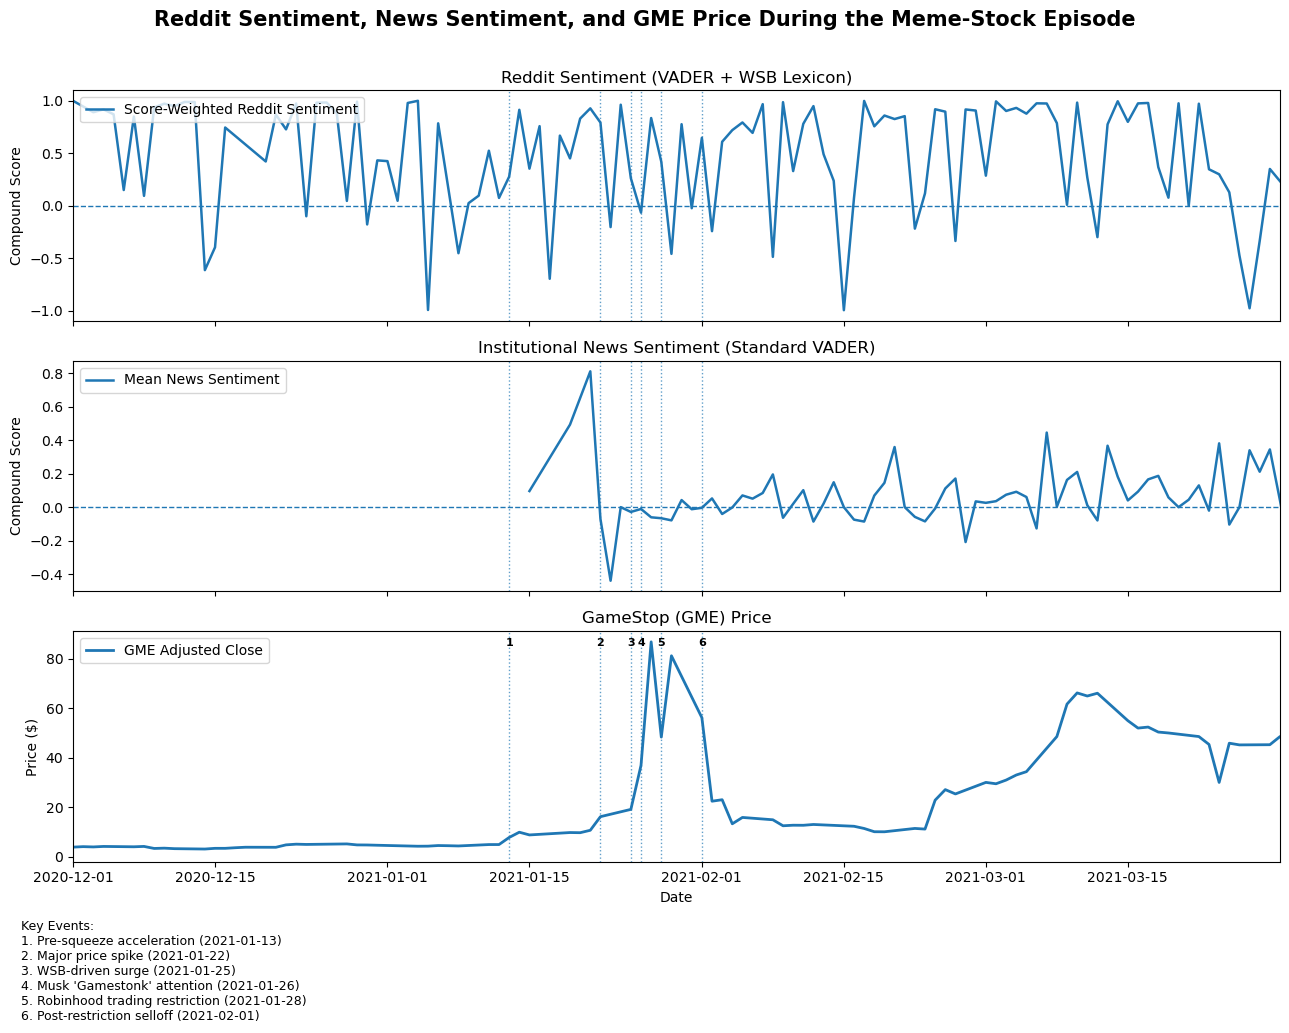

In [67]:
# ---------------------------------------------------------
# 1.8 Visualize Reddit Sentiment, News Sentiment,
#     and GME Price Over Time
# ---------------------------------------------------------

# Prepare plotting data
reddit_plot = reddit_daily.copy()
news_plot = news_daily.copy()

reddit_plot["date"] = pd.to_datetime(reddit_plot["date"])
news_plot["date"] = pd.to_datetime(news_plot["date"])

# GME price series
gme_price = prices[["GME"]].copy()
gme_price.index = pd.to_datetime(gme_price.index)

# Key GME events
TIMELINE_EVENTS = {
    "Pre-squeeze acceleration": pd.Timestamp("2021-01-13"),
    "Major price spike": pd.Timestamp("2021-01-22"),
    "WSB-driven surge": pd.Timestamp("2021-01-25"),
    "Musk 'Gamestonk' attention": pd.Timestamp("2021-01-26"),
    "Robinhood trading restriction": pd.Timestamp("2021-01-28"),
    "Post-restriction selloff": pd.Timestamp("2021-02-01")
}

# Plotting window
PLOT_START = pd.Timestamp("2020-12-01")
PLOT_END = pd.Timestamp("2021-03-30")

# ---------------------------------------------------------
# Create figure
# ---------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

fig.suptitle(
    "Reddit Sentiment, News Sentiment, and GME Price "
    "During the Meme-Stock Episode",
    fontsize=15,
    fontweight="bold",
    y=1.01
)

# ---------------------------------------------------------
# Panel 1: Reddit sentiment
# ---------------------------------------------------------

axes[0].plot(
    reddit_plot["date"],
    reddit_plot["weighted_compound"],
    linewidth=1.8,
    label="Score-Weighted Reddit Sentiment"
)

axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].set_ylabel("Compound Score")
axes[0].set_title("Reddit Sentiment (VADER + WSB Lexicon)")
axes[0].legend(loc="upper left")

# ---------------------------------------------------------
# Panel 2: News sentiment
# ---------------------------------------------------------

axes[1].plot(
    news_plot["date"],
    news_plot["mean_compound"],
    linewidth=1.8,
    label="Mean News Sentiment"
)

axes[1].axhline(0, linestyle="--",linewidth=1)
axes[1].set_ylabel("Compound Score")
axes[1].set_title("Institutional News Sentiment (Standard VADER)")
axes[1].legend(loc="upper left")

# ---------------------------------------------------------
# Panel 3: GME price
# ---------------------------------------------------------

axes[2].plot(
    gme_price.index,
    gme_price["GME"],
    linewidth=2,
    label="GME Adjusted Close"
)

axes[2].set_ylabel("Price ($)")
axes[2].set_xlabel("Date")
axes[2].set_title("GameStop (GME) Price")
axes[2].legend(loc="upper left")

# ---------------------------------------------------------
# Add event reference lines
# ---------------------------------------------------------

for event_num, (event_label, event_date) in enumerate(TIMELINE_EVENTS.items(), start=1):

    # Vertical event lines across all three panels
    for ax in axes:
        ax.axvline(event_date, linestyle=":", linewidth=1, alpha=0.7)

    # Number labels only on the GME price panel
    y_max = axes[2].get_ylim()[1]

    axes[2].annotate(
        str(event_num),
        xy=(event_date, y_max),
        xytext=(0, -5),
        textcoords="offset points",
        ha="center",
        va="top",
        fontsize=8,
        fontweight="bold"
    )

# ---------------------------------------------------------
# Limit plot to analytical period
# ---------------------------------------------------------

for ax in axes:
    ax.set_xlim(PLOT_START, PLOT_END)

# ---------------------------------------------------------
# Event key
# ---------------------------------------------------------

event_text = "\n".join(
    f"{i}. {label} ({date.date()})"
    for i, (label, date) in enumerate(
        TIMELINE_EVENTS.items(),
        start=1
    )
)

fig.text(0.02, 0.1, "Key Events:\n" + event_text, fontsize=9, va="top")

# ---------------------------------------------------------
# Final formatting and save
# ---------------------------------------------------------

plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.savefig(FIG_DIR / "fig_sentiment_gme_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

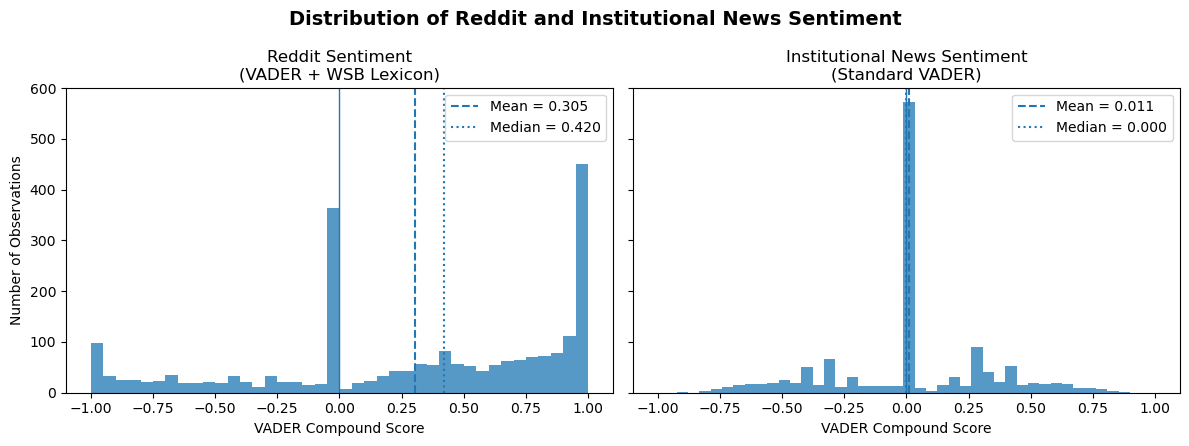

In [57]:
# ---------------------------------------------------------
# 1.9 Compare Reddit and News Sentiment Distributions
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4.5),
    sharex=True,
    sharey=True
)

# ---------------------------------------------------------
# Reddit
# ---------------------------------------------------------

axes[0].hist(
    reddit["vader_compound"],
    bins=40,
    alpha=0.75
)

reddit_mean = reddit["vader_compound"].mean()
reddit_median = reddit["vader_compound"].median()

axes[0].axvline(
    reddit_mean,
    linestyle="--",
    linewidth=1.5,
    label=f"Mean = {reddit_mean:.3f}"
)

axes[0].axvline(
    reddit_median,
    linestyle=":",
    linewidth=1.5,
    label=f"Median = {reddit_median:.3f}"
)

axes[0].axvline(
    0,
    linewidth=1
)

axes[0].set_title(
    "Reddit Sentiment\n(VADER + WSB Lexicon)"
)

axes[0].set_xlabel("VADER Compound Score")
axes[0].set_ylabel("Number of Observations")
axes[0].legend()


# ---------------------------------------------------------
# News
# ---------------------------------------------------------

axes[1].hist(
    news["vader_compound"],
    bins=40,
    alpha=0.75
)

news_mean = news["vader_compound"].mean()
news_median = news["vader_compound"].median()

axes[1].axvline(
    news_mean,
    linestyle="--",
    linewidth=1.5,
    label=f"Mean = {news_mean:.3f}"
)

axes[1].axvline(
    news_median,
    linestyle=":",
    linewidth=1.5,
    label=f"Median = {news_median:.3f}"
)

axes[1].axvline(
    0,
    linewidth=1
)

axes[1].set_title(
    "Institutional News Sentiment\n(Standard VADER)"
)

axes[1].set_xlabel("VADER Compound Score")
axes[1].legend()


fig.suptitle(
    "Distribution of Reddit and Institutional News Sentiment",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig_sentiment_distributions.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 2 - Topic Modeling (LDA)

In [16]:
# ---------------------------------------------------------
# 2.1 Prepare Text for Topic Modeling
# ---------------------------------------------------------

# Add domain-specific stopwords
custom_stop_words = {
    # Domain terms appearing frequently across documents
    "gme",
    "gamestop",
    "stock",
    "stocks",
    "share",
    "shares",
    "reddit",

    # General conversational words with limited topic value
    "just",
    "like",
    "people",
    "don",
    "going",
    "know",
    "time",
    "new",
    "think",
    "click"
}

stop_words = set(ENGLISH_STOP_WORDS) | custom_stop_words


def clean_text_for_lda(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove non-letter characters
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stopwords and very short words
    tokens = [word for word in text.split() if word not in stop_words and len(word) > 2]

    return " ".join(tokens)

In [17]:
# ---------------------------------------------------------
# 2.2 Clean Reddit and News Text for LDA
# ---------------------------------------------------------

reddit["lda_text"] = reddit["text"].apply(clean_text_for_lda)
news["lda_text"] = news["text"].apply(clean_text_for_lda)

print("Empty Reddit LDA text:")
print(reddit["lda_text"].eq("").sum())

print("\nEmpty News LDA text:")
print(news["lda_text"].eq("").sum())

Empty Reddit LDA text:
17

Empty News LDA text:
2


In [18]:
# ---------------------------------------------------------
# 2.3 Inspect Most Frequent Terms After Cleaning
# ---------------------------------------------------------

reddit_words = Counter(
    " ".join(
        reddit.loc[reddit["lda_text"] != "", "lda_text"]
    ).split()
)

news_words = Counter(
    " ".join(
        news.loc[news["lda_text"] != "", "lda_text"]
    ).split()
)

print("Top Reddit words:")
print(reddit_words.most_common(20))

print("\nTop News words:")
print(news_words.most_common(20))

Top Reddit words:
[('short', 3073), ('price', 1904), ('market', 1782), ('buy', 1480), ('squeeze', 1376), ('company', 1141), ('money', 1092), ('shorts', 1063), ('hedge', 899), ('long', 875), ('sell', 866), ('make', 839), ('funds', 752), ('buying', 733), ('day', 731), ('retail', 707), ('amc', 687), ('trading', 686), ('cohen', 686), ('week', 671)]

Top News words:
[('robinhood', 153), ('amc', 149), ('wall', 109), ('short', 107), ('street', 107), ('market', 102), ('wallstreetbets', 101), ('trading', 85), ('nyse', 84), ('corporation', 74), ('investors', 72), ('silver', 68), ('rally', 65), ('squeeze', 62), ('meme', 52), ('price', 50), ('traders', 50), ('investor', 45), ('surge', 44), ('retail', 44)]


In [19]:
# ---------------------------------------------------------
# 2.4 Prepare Reddit and News documents for LDA
# ---------------------------------------------------------

reddit_lda = reddit[
    reddit["lda_text"].ne("")
].copy()

news_lda = news[
    news["lda_text"].ne("")
].copy()

print("Reddit documents for LDA:", len(reddit_lda))
print("News documents for LDA:", len(news_lda))

Reddit documents for LDA: 2344
News documents for LDA: 1332


In [20]:
# ---------------------------------------------------------
# 2.5 Create Document-Term Matrices
# ---------------------------------------------------------

# Reddit
reddit_vectorizer = CountVectorizer(
    min_df=5,
    max_df=0.95
)

reddit_dtm = reddit_vectorizer.fit_transform(
    reddit_lda["lda_text"]
)

reddit_terms = reddit_vectorizer.get_feature_names_out()


# News
news_vectorizer = CountVectorizer(
    min_df=3,
    max_df=0.95
)

news_dtm = news_vectorizer.fit_transform(
    news_lda["lda_text"]
)

news_terms = news_vectorizer.get_feature_names_out()


print("Reddit document-term matrix shape:", reddit_dtm.shape)
print("Reddit vocabulary size:", len(reddit_terms))

print("\nNews document-term matrix shape:", news_dtm.shape)
print("News vocabulary size:", len(news_terms))

Reddit document-term matrix shape: (2344, 4987)
Reddit vocabulary size: 4987

News document-term matrix shape: (1332, 739)
News vocabulary size: 739


In [21]:
# ---------------------------------------------------------
# 2.6 Fit Reddit and News LDA Models
# ---------------------------------------------------------

N_TOPICS = 5

reddit_lda_model = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    learning_method="online",
    max_iter=20
)

news_lda_model = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    learning_method="online",
    max_iter=20
)

reddit_lda_model.fit(reddit_dtm)
print("Reddit LDA model fitted.")

news_lda_model.fit(news_dtm)
print("News LDA model fitted.")

Reddit LDA model fitted.
News LDA model fitted.


In [22]:
# ---------------------------------------------------------
# 2.7 Display Top Words for Reddit and News LDA Topics
# ---------------------------------------------------------

N_WORDS = 10

print("Five Reddit LDA Topics:")

for topic_idx, topic in enumerate(reddit_lda_model.components_):

    top_indices = topic.argsort()[-N_WORDS:][::-1]

    top_words = [
        reddit_terms[i]
        for i in top_indices
    ]

    print(
        f"Topic {topic_idx + 1}: "
        + ", ".join(top_words)
    )

print("\nFive News LDA Topics:")
for topic_idx, topic in enumerate(news_lda_model.components_):

    top_indices = topic.argsort()[-N_WORDS:][::-1]

    top_words = [news_terms[i] for i in top_indices]

    print(
        f"Topic {topic_idx + 1}: "
        + ", ".join(top_words)
    )

Five Reddit LDA Topics:
Topic 1: money, make, buy, want, sell, let, fucking, hold, right, shit
Topic 2: short, price, squeeze, shorts, market, options, volume, positions, long, hedge
Topic 3: silver, robinhood, market, trading, investors, citadel, short, amc, brokers, deliver
Topic 4: earnings, market, week, year, buy, amc, day, chart, company, money
Topic 5: company, cohen, board, ryan, gaming, sales, amc, games, digital, revenue

Five News LDA Topics:
Topic 1: short, squeeze, rally, wallstreetbets, redditors, high, tesla, musk, day, sellers
Topic 2: wall, street, investors, market, traders, dow, retail, hedge, funds, game
Topic 3: amc, nyse, corporation, price, silver, today, corp, market, short, blackberry
Topic 4: robinhood, market, watch, news, stories, investment, rocket, media, buying, users
Topic 5: trading, meme, money, business, financial, buy, kitty, roaring, saga, rally


In [23]:
# ---------------------------------------------------------
# 2.8 Assign Dominant LDA Topic to Each Document
# ---------------------------------------------------------

# Reddit
reddit_topic_probs = reddit_lda_model.transform(reddit_dtm)

reddit_lda["dominant_topic"] = (
    reddit_topic_probs.argmax(axis=1) + 1
)

reddit_lda["topic_probability"] = (
    reddit_topic_probs.max(axis=1)
)

# News
news_topic_probs = news_lda_model.transform(news_dtm)

news_lda["dominant_topic"] = (
    news_topic_probs.argmax(axis=1) + 1
)

news_lda["topic_probability"] = (
    news_topic_probs.max(axis=1)
)

print("Reddit topic distribution:")
print(
    reddit_lda["dominant_topic"]
    .value_counts()
    .sort_index()
)

print("\nNews topic distribution:")
print(
    news_lda["dominant_topic"]
    .value_counts()
    .sort_index()
)

Reddit topic distribution:
dominant_topic
1    1052
2     430
3     228
4     460
5     174
Name: count, dtype: int64

News topic distribution:
dominant_topic
1    295
2    267
3    319
4    230
5    221
Name: count, dtype: int64


In [24]:
# ---------------------------------------------------------
# 2.9 Display Representative Documents for Each LDA Topic
# ---------------------------------------------------------

N_DOCS = 5

print("=== REDDIT REPRESENTATIVE DOCUMENTS ===")

for topic in range(1, 6):
    
    examples = (
        reddit_lda[
            reddit_lda["dominant_topic"] == topic
        ]
        .sort_values(
            "topic_probability",
            ascending=False
        )
        .head(N_DOCS)
    )

    print(f"\n--- Reddit Topic {topic} ---")
    
    display(
        examples[
            ["date", "topic_probability", "text"]
        ]
    )


print("\n=== NEWS REPRESENTATIVE DOCUMENTS ===")

for topic in range(1, 6):
    
    examples = (
        news_lda[
            news_lda["dominant_topic"] == topic
        ]
        .sort_values(
            "topic_probability",
            ascending=False
        )
        .head(N_DOCS)
    )

    print(f"\n--- News Topic {topic} ---")
    
    display(
        examples[
            ["date", "topic_probability", "text"]
        ]
    )

=== REDDIT REPRESENTATIVE DOCUMENTS ===

--- Reddit Topic 1 ---


,date,topic_probability,text
1359,2021-02-01,0.995011,"GME Inspiration 💎🙏 🚀🚀🚀🚀 Today we had it hard, ..."
1593,2021-02-04,0.994818,Let’s face it. Listen up retards. I know nobod...
2347,2021-03-27,0.993850,Michael Jordan has NO proven connection to Gam...
698,2021-01-28,0.992577,"Ya'll, this is bigger than it seems. You have ..."
128,2021-01-11,0.991336,Smart money will bet on RC and a GME turnaroun...



--- Reddit Topic 2 ---


,date,topic_probability,text
1754,2021-02-05,0.997500,Updated Short Interest Numbers for GameStop (G...
447,2021-01-27,0.996377,List of fake news articles claiming Melvin Cap...
2211,2021-03-11,0.992580,"Forbes's quant professor confirms Gamma Swarm,..."
1304,2021-02-01,0.992436,GameStop Secondary Offering: What it might loo...
227,2021-01-20,0.990576,Even the big dogs see the short squeeze. They'...



--- Reddit Topic 3 ---


...

,date,topic_probability,text
593,2021-02-01,0.946289,"AMC Entertainment Holdings ( AMC ), Gamestop C..."
106,2021-01-27,0.938428,"AMC Entertainment Holdings ( AMC ), Bed Bath &..."
506,2021-01-31,0.938318,"Apple ( AAPL ), AMC Entertainment Holdings ( A..."
866,2021-02-08,0.938145,"AMC Entertainment Holdings ( AMC ), Canopy Gro..."
949,2021-02-14,0.933161,"AMC Entertainment Holdings ( AMC ), Blackrock ..."



--- News Topic 4 ---


,date,topic_probability,text
288,2021-01-28,0.919920,How is this legal ? Investment companies like ...
230,2021-01-28,0.919920,How is this legal ? Investment companies like ...
807,2021-02-05,0.910532,"SEC Is Reviewing Social Media Posts , Agency I..."
298,2021-01-28,0.899999,Robinhood lawsuit 2021 : Class action filed ag...
296,2021-01-28,0.899866,Robinhood Faces Class - Action Lawsuit for Blo...



--- News Topic 5 ---


,date,topic_probability,text
1070,2021-02-25,0.927171,GameStop rally builds after puzzling ice - cre...
1058,2021-02-25,0.919911,GameStop rallies again ; some puzzle over ice ...
462,2021-01-30,0.910666,UPDATE 1 - Famed GameStop bull Roaring Kitty i...
445,2021-01-30,0.899998,Famed GameStop bull Roaring Kitty is a Massach...
329,2021-01-29,0.899998,Famed GameStop bull Roaring Kitty is a Massach...


In [25]:
# ---------------------------------------------------------
# 2.10 Inspect Market Data Before Market Movement Labeling
# ---------------------------------------------------------

print("Returns shape:", returns.shape)
print("Returns columns:", returns.columns.tolist())
display(returns.head())

print("\nVolume shape:", volume.shape)
print("Volume columns:", volume.columns.tolist())
display(volume.head())

Returns shape: (125, 4)
Returns columns: ['GME', 'SPY', 'AMC', 'BB']


,GME,SPY,AMC,BB
date,,,,
2020-10-01,NaN,NaN,NaN,NaN
2020-10-02,-0.039671,-0.009540,0.000000,-0.031045
2020-10-05,0.007427,0.017578,-0.118590,0.013423
2020-10-06,-0.035507,-0.014318,-0.017094,0.011050
2020-10-07,0.024880,0.017257,-0.004938,0.004386



Volume shape: (125, 4)
Volume columns: ['GME', 'SPY', 'AMC', 'BB']


,GME,SPY,AMC,BB
date,,,,
2020-10-01,18216400,88698700,322380,4971200
2020-10-02,17362000,89431100,357600,6539300
2020-10-05,11220000,45713100,946880,3106300
2020-10-06,18141600,90128900,840420,3966000
2020-10-07,13234400,56999600,691770,2166900


In [26]:
# ---------------------------------------------------------
# 2.11 Create Market Movement Variables
# ---------------------------------------------------------

ret_gme = returns["GME"].copy()
ret_gme.index = pd.to_datetime(ret_gme.index).normalize()

market = pd.DataFrame({
    "ret_gme": ret_gme,
    "ret_gme_next": ret_gme.shift(-1),
    "ret_spy": returns["SPY"],
    "log_vol_gme": np.log1p(volume["GME"])
})

market.index = pd.to_datetime(market.index).normalize()

# Remove observations without a known next-day GME return
market = market.dropna(
    subset=["ret_gme_next"]
).copy()

# Binary target:
# 1 = positive GME return on the next trading day
# 0 = zero or negative GME return on the next trading day
market["up_next"] = (
    market["ret_gme_next"] > 0
).astype(int)

print("Market dataset shape:", market.shape)
display(market.head(10))

Market dataset shape: (124, 5)


,ret_gme,ret_gme_next,ret_spy,log_vol_gme,up_next
date,,,,,
2020-10-01,NaN,-0.039671,NaN,16.717833,0
2020-10-02,-0.039671,0.007427,-0.009540,16.669795,1
2020-10-05,0.007427,-0.035507,0.017578,16.233209,0
2020-10-06,-0.035507,0.024880,-0.014318,16.713718,1
2020-10-07,0.024880,0.365503,0.017257,16.398330,1
2020-10-08,0.365503,-0.115377,0.008824,19.538489,0
2020-10-09,-0.115377,-0.018472,0.008891,19.547593,0
2020-10-12,-0.018472,0.006757,0.015959,18.365409,1
2020-10-13,0.006757,0.030670,-0.006547,17.522200,1


In [27]:
# ---------------------------------------------------------
# 2.12 Merge Daily Sentiment with Market Data
# ---------------------------------------------------------

# Prepare Reddit daily features
reddit_daily_merge = (
    reddit_daily
    .rename(
        columns={
            "mean_compound": "reddit_mean_compound",
            "post_count": "reddit_post_count",
            "total_score": "reddit_total_score",
            "weighted_compound": "reddit_weighted_compound"
        }
    )
    .set_index("date")
)

# Prepare News daily features
news_daily_merge = (
    news_daily
    .rename(
        columns={
            "mean_compound": "news_mean_compound",
            "article_count": "news_article_count"
        }
    )
    .set_index("date")
)

# Ensure normalized datetime indices
reddit_daily_merge.index = (
    pd.to_datetime(reddit_daily_merge.index).normalize()
)

news_daily_merge.index = (
    pd.to_datetime(news_daily_merge.index).normalize()
)

market.index = (
    pd.to_datetime(market.index).normalize()
)

# Merge onto trading-day market data
master = (
    market
    .join(reddit_daily_merge, how="left")
    .join(news_daily_merge, how="left")
    .sort_index()
)

print("Master dataset shape:", master.shape)

display(master.head(10))

Master dataset shape: (124, 11)


,ret_gme,ret_gme_next,ret_spy,log_vol_gme,up_next,reddit_mean_compound,reddit_post_count,reddit_total_score,reddit_weighted_compound,news_mean_compound,news_article_count
date,,,,,,,,,,,
2020-10-01,NaN,-0.039671,NaN,16.717833,0,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-02,-0.039671,0.007427,-0.009540,16.669795,1,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-05,0.007427,-0.035507,0.017578,16.233209,0,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-06,-0.035507,0.024880,-0.014318,16.713718,1,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-07,0.024880,0.365503,0.017257,16.398330,1,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-08,0.365503,-0.115377,0.008824,19.538489,0,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-09,-0.115377,-0.018472,0.008891,19.547593,0,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-12,-0.018472,0.006757,0.015959,18.365409,1,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-13,0.006757,0.030670,-0.006547,17.522200,1,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
# ---------------------------------------------------------
# 2.13 Validate Data Coverage After Merge
# ---------------------------------------------------------

print("Master dataset shape:")
print(master.shape)

print("\nDate range:")
print(master.index.min(), "→", master.index.max())

print("\nMissing values:")
print(
    master[
        [
            "reddit_mean_compound",
            "reddit_weighted_compound",
            "reddit_post_count",
            "news_mean_compound",
            "news_article_count"
        ]
    ]
    .isna()
    .sum()
)

print("\nTrading days with Reddit data:")
print(master["reddit_mean_compound"].notna().sum())

print("\nTrading days with News data:")
print(master["news_mean_compound"].notna().sum())

print("\nTrading days with both Reddit and News data:")
print(
    (
        master["reddit_mean_compound"].notna()
        & master["news_mean_compound"].notna()
    ).sum()
)

print("\nTrading days with neither source:")
print(
    (
        master["reddit_mean_compound"].isna()
        & master["news_mean_compound"].isna()
    ).sum()
)

Master dataset shape:
(124, 11)

Date range:
2020-10-01 00:00:00 → 2021-03-30 00:00:00

Missing values:
reddit_mean_compound        46
reddit_weighted_compound    46
reddit_post_count           46
news_mean_compound          74
news_article_count          74
dtype: int64

Trading days with Reddit data:
78

Trading days with News data:
50

Trading days with both Reddit and News data:
50

Trading days with neither source:
46


In [29]:
# ---------------------------------------------------------
# 2.14 Inspect Aligned Date Coverage by Source
# ---------------------------------------------------------

reddit_market_dates = master.index[
    master["reddit_mean_compound"].notna()
]

news_market_dates = master.index[
    master["news_mean_compound"].notna()
]

both_market_dates = master.index[
    master["reddit_mean_compound"].notna()
    & master["news_mean_compound"].notna()
]

print("Reddit trading-day coverage:")
print(reddit_market_dates.min(), "→", reddit_market_dates.max())

print("\nNews trading-day coverage:")
print(news_market_dates.min(), "→", news_market_dates.max())

print("\nOverlapping trading-day coverage:")
print(both_market_dates.min(), "→", both_market_dates.max())

Reddit trading-day coverage:
2020-12-01 00:00:00 → 2021-03-30 00:00:00

News trading-day coverage:
2021-01-15 00:00:00 → 2021-03-30 00:00:00

Overlapping trading-day coverage:
2021-01-15 00:00:00 → 2021-03-30 00:00:00


In [30]:
# ---------------------------------------------------------
# 2.15 Feature Engineering
# ---------------------------------------------------------

# Previous-trading-day sentiment and activity features
master["reddit_sent_lag1"] = master["reddit_weighted_compound"].shift(1)
master["news_sent_lag1"] = master["news_mean_compound"].shift(1)
master["reddit_vol_lag1"] = master["reddit_post_count"].shift(1)

# Difference between Reddit and News sentiment
master["sent_divergence"] = master["reddit_weighted_compound"] - master["news_mean_compound"]
master["sent_div_lag1"] = master["sent_divergence"].shift(1)

# Standardized log GME trading volume
master["log_vol_z"] = ((master["log_vol_gme"] - master["log_vol_gme"].mean()) / master["log_vol_gme"].std())

print("Features added:")
print([
    "reddit_sent_lag1",
    "news_sent_lag1",
    "reddit_vol_lag1",
    "sent_divergence",
    "sent_div_lag1",
    "log_vol_z"
])

display(
    master[
        [
            "reddit_weighted_compound",
            "reddit_sent_lag1",
            "news_mean_compound",
            "news_sent_lag1",
            "sent_divergence",
            "sent_div_lag1",
            "reddit_post_count",
            "reddit_vol_lag1",
            "log_vol_z"
        ]
    ].tail(10)
)

Features added:
['reddit_sent_lag1', 'news_sent_lag1', 'reddit_vol_lag1', 'sent_divergence', 'sent_div_lag1', 'log_vol_z']


,reddit_weighted_compound,reddit_sent_lag1,news_mean_compound,news_sent_lag1,sent_divergence,sent_div_lag1,reddit_post_count,reddit_vol_lag1,log_vol_z
date,,,,,,,,,
2021-03-17,0.978698,0.974556,0.166086,0.092922,0.812612,0.881634,13.0,12.0,0.027445
2021-03-18,0.368450,0.978698,0.187186,0.166086,0.181264,0.812612,7.0,13.0,-0.301008
2021-03-19,0.077200,0.368450,0.058513,0.187186,0.018688,0.181264,2.0,7.0,0.420702
2021-03-22,0.971800,0.077200,0.130117,0.058513,0.841683,0.018688,7.0,2.0,-0.453389
2021-03-23,0.347431,0.971800,-0.020743,0.130117,0.368174,0.841683,19.0,7.0,-0.102132
2021-03-24,0.299664,0.347431,0.381740,-0.020743,-0.082076,0.368174,12.0,19.0,0.400783
2021-03-25,0.128068,0.299664,-0.104280,0.381740,0.232348,-0.082076,9.0,12.0,1.127251
2021-03-26,-0.472841,0.128068,0.000000,-0.104280,-0.472841,0.232348,4.0,9.0,0.826593
2021-03-29,0.350533,-0.472841,0.345400,0.000000,0.005133,-0.472841,3.0,4.0,-0.455260


In [31]:
# ---------------------------------------------------------
# 2.16 Validate Usable Observations for Predictive Modeling
# ---------------------------------------------------------

reddit_required = [
    "reddit_sent_lag1",
    "reddit_vol_lag1",
    "ret_gme",
    "ret_spy",
    "log_vol_z",
    "up_next"
]

news_required = [
    "news_sent_lag1",
    "ret_gme",
    "ret_spy",
    "log_vol_z",
    "up_next"
]

combined_required = [
    "reddit_sent_lag1",
    "news_sent_lag1",
    "reddit_vol_lag1",
    "sent_div_lag1",
    "ret_gme",
    "ret_spy",
    "log_vol_z",
    "up_next"
]

print("Usable observations after feature engineering:")
print(f"Reddit sample: {master[reddit_required].dropna().shape[0]}")
print(f"News sample: {master[news_required].dropna().shape[0]}")
print(f"Combined sample: {master[combined_required].dropna().shape[0]}")

Usable observations after feature engineering:
Reddit sample: 77
News sample: 49
Combined sample: 49


## 3 - Predictive Modeling


In [32]:
# ---------------------------------------------------------
# 3.1 Create Analytical Samples for Predictive Modeling
# ---------------------------------------------------------

reddit_sample = master[reddit_required].dropna().copy()
news_sample = master[news_required].dropna().copy()
combined_sample = master[combined_required].dropna().copy()

print("Analytical sample sizes:")
print("Reddit sample:", reddit_sample.shape)
print("News sample:", news_sample.shape)
print("Combined sample:", combined_sample.shape)

print("\nTarget distribution (up_next):")

print("\nReddit:")
print(reddit_sample["up_next"].value_counts().sort_index())

print("\nNews:")
print(news_sample["up_next"].value_counts().sort_index())

print("\nCombined:")
print(combined_sample["up_next"].value_counts().sort_index())

Analytical sample sizes:
Reddit sample: (77, 6)
News sample: (49, 5)
Combined sample: (49, 8)

Target distribution (up_next):

Reddit:
up_next
0    39
1    38
Name: count, dtype: int64

News:
up_next
0    25
1    24
Name: count, dtype: int64

Combined:
up_next
0    25
1    24
Name: count, dtype: int64


In [33]:
# ------------------------------------------------------------
# 3.2 Define Feature Sets for Predictive Modeling
# ------------------------------------------------------------

FEATURE_SETS = {
    "Reddit-only": (
        [
            "reddit_sent_lag1",
            "reddit_vol_lag1",
            "ret_gme",
            "ret_spy",
            "log_vol_z"
        ],
        reddit_sample
    ),

    "News-only": (
        [
            "news_sent_lag1",
            "ret_gme",
            "ret_spy",
            "log_vol_z"
        ],
        news_sample
    ),

    "Combined": (
        [
            "reddit_sent_lag1",
            "news_sent_lag1",
            "reddit_vol_lag1",
            "ret_gme",
            "ret_spy",
            "log_vol_z"
        ],
        combined_sample
    )
}

for name, (features, data) in FEATURE_SETS.items():
    print(f"{name}:")
    print(f"  Observations: {len(data)}")
    print(f"  Features ({len(features)}): {features}")

Reddit-only:
  Observations: 77
  Features (5): ['reddit_sent_lag1', 'reddit_vol_lag1', 'ret_gme', 'ret_spy', 'log_vol_z']
News-only:
  Observations: 49
  Features (4): ['news_sent_lag1', 'ret_gme', 'ret_spy', 'log_vol_z']
Combined:
  Observations: 49
  Features (6): ['reddit_sent_lag1', 'news_sent_lag1', 'reddit_vol_lag1', 'ret_gme', 'ret_spy', 'log_vol_z']


In [34]:
# ------------------------------------------------------------
# 3.3 Configure Predictive Models and Time-Aware Cross-Validation
# ------------------------------------------------------------

# Time-aware cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Models
MODELS = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=500,
            random_state=42
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

print("Cross-validation:")
print(tscv)

print("\nModels:")
for name in MODELS:
    print("-", name)

Cross-validation:
TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)

Models:
- Logistic Regression
- Random Forest


In [35]:
# ------------------------------------------------------------
# 3.4 Validate Class Balance Across Time-Series CV Folds
# ------------------------------------------------------------

for sample_name, (features, data) in FEATURE_SETS.items():

    X = data[features]
    y = data["up_next"]

    print(f"\n=== {sample_name} ===")

    for fold, (train_idx, test_idx) in enumerate(
        tscv.split(X),
        start=1
    ):
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        print(
            f"Fold {fold}: "
            f"Train n={len(train_idx)} "
            f"{y_train.value_counts().sort_index().to_dict()} | "
            f"Test n={len(test_idx)} "
            f"{y_test.value_counts().sort_index().to_dict()}"
        )


=== Reddit-only ===
Fold 1: Train n=17 {0: 10, 1: 7} | Test n=12 {0: 5, 1: 7}
Fold 2: Train n=29 {0: 15, 1: 14} | Test n=12 {0: 5, 1: 7}
Fold 3: Train n=41 {0: 20, 1: 21} | Test n=12 {0: 7, 1: 5}
Fold 4: Train n=53 {0: 27, 1: 26} | Test n=12 {0: 4, 1: 8}
Fold 5: Train n=65 {0: 31, 1: 34} | Test n=12 {0: 8, 1: 4}

=== News-only ===
Fold 1: Train n=9 {0: 4, 1: 5} | Test n=8 {0: 4, 1: 4}
Fold 2: Train n=17 {0: 8, 1: 9} | Test n=8 {0: 5, 1: 3}
Fold 3: Train n=25 {0: 13, 1: 12} | Test n=8 {0: 2, 1: 6}
Fold 4: Train n=33 {0: 15, 1: 18} | Test n=8 {0: 5, 1: 3}
Fold 5: Train n=41 {0: 20, 1: 21} | Test n=8 {0: 5, 1: 3}

=== Combined ===
Fold 1: Train n=9 {0: 4, 1: 5} | Test n=8 {0: 4, 1: 4}
Fold 2: Train n=17 {0: 8, 1: 9} | Test n=8 {0: 5, 1: 3}
Fold 3: Train n=25 {0: 13, 1: 12} | Test n=8 {0: 2, 1: 6}
Fold 4: Train n=33 {0: 15, 1: 18} | Test n=8 {0: 5, 1: 3}
Fold 5: Train n=41 {0: 20, 1: 21} | Test n=8 {0: 5, 1: 3}


In [36]:
# ------------------------------------------------------------
# 3.5 Evaluate Predictive Models with Time-Series Cross-Validation
# ------------------------------------------------------------

model_results = []

for sample_name, (features, data) in FEATURE_SETS.items():

    X = data[features]
    y = data["up_next"]

    for model_name, model in MODELS.items():

        for fold, (train_idx, test_idx) in enumerate(
            tscv.split(X),
            start=1
        ):

            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]

            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]

            # Fit model using past observations only
            model.fit(X_train, y_train)

            # Predictions
            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)[:, 1]

            # Store fold-level performance
            model_results.append({
                "Feature Set": sample_name,
                "Model": model_name,
                "Fold": fold,
                "Accuracy": accuracy_score(y_test, y_pred),
                "F1": f1_score(y_test, y_pred),
                "ROC_AUC": roc_auc_score(y_test, y_prob)
            })

model_results = pd.DataFrame(model_results)

display(model_results)

,Feature Set,Model,Fold,Accuracy,F1,ROC_AUC
0,Reddit-only,Logistic Regression,1,0.666667,0.666667,0.714286
1,Reddit-only,Logistic Regression,2,0.583333,0.736842,0.114286
2,Reddit-only,Logistic Regression,3,0.333333,0.333333,0.257143
3,Reddit-only,Logistic Regression,4,0.666667,0.777778,0.406250
4,Reddit-only,Logistic Regression,5,0.416667,0.461538,0.687500
5,Reddit-only,Random Forest,1,0.500000,0.625000,0.471429
6,Reddit-only,Random Forest,2,0.500000,0.571429,0.571429
7,Reddit-only,Random Forest,3,0.333333,0.333333,0.257143
8,Reddit-only,Random Forest,4,0.750000,0.800000,0.656250
9,Reddit-only,Random Forest,5,0.500000,0.571429,0.718750


In [37]:
# ------------------------------------------------------------
# 3.6 Summarize cross-validation performance
# ------------------------------------------------------------

cv_summary = (
    model_results
    .groupby(["Feature Set", "Model"])
    .agg(
        Mean_Accuracy=("Accuracy", "mean"),
        SD_Accuracy=("Accuracy", "std"),
        Mean_F1=("F1", "mean"),
        SD_F1=("F1", "std"),
        Mean_ROC_AUC=("ROC_AUC", "mean"),
        SD_ROC_AUC=("ROC_AUC", "std")
    )
    .reset_index()
)

display(
    cv_summary.round(3)
)

,Feature Set,Model,Mean_Accuracy,SD_Accuracy,Mean_F1,SD_F1,Mean_ROC_AUC,SD_ROC_AUC
0,Combined,Logistic Regression,0.400,0.056,0.387,0.220,0.472,0.214
1,Combined,Random Forest,0.450,0.227,0.502,0.204,0.545,0.305
2,News-only,Logistic Regression,0.475,0.163,0.303,0.280,0.475,0.167
3,News-only,Random Forest,0.600,0.285,0.549,0.327,0.613,0.387
4,Reddit-only,Logistic Regression,0.533,0.151,0.595,0.190,0.436,0.263
5,Reddit-only,Random Forest,0.517,0.149,0.580,0.167,0.535,0.181


In [38]:
# ---------------------------------------------------------
# 3.7 OLS regression analysis
# ---------------------------------------------------------

MODEL_SPECS = {
    "M1 Reddit-only": [
        "reddit_sent_lag1",
        "ret_gme",
        "ret_spy",
        "log_vol_z"
    ],

    "M2 News-only": [
        "news_sent_lag1",
        "ret_gme",
        "ret_spy",
        "log_vol_z"
    ],

    "M3 Combined": [
        "reddit_sent_lag1",
        "news_sent_lag1",
        "ret_gme",
        "ret_spy",
        "log_vol_z"
    ],

    # Use divergence instead of including it together
    # with its two component sentiment variables
    "M4 Divergence": [
        "sent_div_lag1",
        "ret_gme",
        "ret_spy",
        "log_vol_z"
    ]
}

ols_results = {}

print(
    "OLS Results "
    "(HAC/Newey-West SEs, dependent = ret_gme_next)\n"
)

for name, x_cols in MODEL_SPECS.items():

    # Keep only observations available for this model
    sub = master[
        ["ret_gme_next"] + x_cols
    ].dropna()

    y = sub["ret_gme_next"]
    X = sm.add_constant(sub[x_cols])

    # OLS with HAC/Newey-West standard errors
    result = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 5}
    )

    ols_results[name] = result

    print(
        f"{name}: "
        f"R²={result.rsquared:.4f}  "
        f"Adj-R²={result.rsquared_adj:.4f}  "
        f"F-pval={result.f_pvalue:.4f}  "
        f"N={int(result.nobs)}"
    )

    # Display sentiment-related coefficients
    sentiment_vars = [
        c for c in x_cols
        if "sent" in c or "div" in c
    ]

    for var in sentiment_vars:

        coef = result.params[var]
        pval = result.pvalues[var]

        stars = (
            "***" if pval < 0.01
            else "**" if pval < 0.05
            else "*" if pval < 0.10
            else ""
        )

        print(
            f"    {var:<28} "
            f"b={coef:+.6f}  "
            f"p={pval:.4f} {stars}"
        )

    print()

OLS Results (HAC/Newey-West SEs, dependent = ret_gme_next)

M1 Reddit-only: R²=0.0649  Adj-R²=0.0129  F-pval=0.7392  N=77
    reddit_sent_lag1             b=+0.092189  p=0.2989 

M2 News-only: R²=0.0452  Adj-R²=-0.0416  F-pval=0.8236  N=49
    news_sent_lag1               b=-0.042894  p=0.7969 

M3 Combined: R²=0.1054  Adj-R²=0.0013  F-pval=0.7569  N=49
    reddit_sent_lag1             b=+0.168481  p=0.2833 
    news_sent_lag1               b=-0.116685  p=0.4161 

M4 Divergence: R²=0.1046  Adj-R²=0.0232  F-pval=0.6506  N=49
    sent_div_lag1                b=+0.164621  p=0.2572 



In [ ]:
# ---------------------------------------------------------
# 3.8 Summarize OLS Sentiment Coefficients
# ---------------------------------------------------------

coef_rows = []

for model_name, result in ols_results.items():

    for var in result.params.index:

        # Keep only sentiment-related variables
        if "sent" in var or "div" in var:

            coef_rows.append({
                "Model": model_name,
                "Variable": var,
                "Coefficient": result.params[var],
                "SE": result.bse[var],
                "Lower_95": result.params[var] - 1.96 * result.bse[var],
                "Upper_95": result.params[var] + 1.96 * result.bse[var],
                "P_value": result.pvalues[var]
            })

coef_df = pd.DataFrame(coef_rows)

display(coef_df.round(4))

,Model,Variable,Coefficient,SE,Lower_95,Upper_95,P_value
0,M1 Reddit-only,reddit_sent_lag1,0.0922,0.0887,-0.0818,0.2661,0.2989
1,M2 News-only,news_sent_lag1,-0.0429,0.1667,-0.3696,0.2838,0.7969
2,M3 Combined,reddit_sent_lag1,0.1685,0.1570,-0.1393,0.4762,0.2833
3,M3 Combined,news_sent_lag1,-0.1167,0.1435,-0.3979,0.1645,0.4161
4,M4 Divergence,sent_div_lag1,0.1646,0.1453,-0.1202,0.4494,0.2572


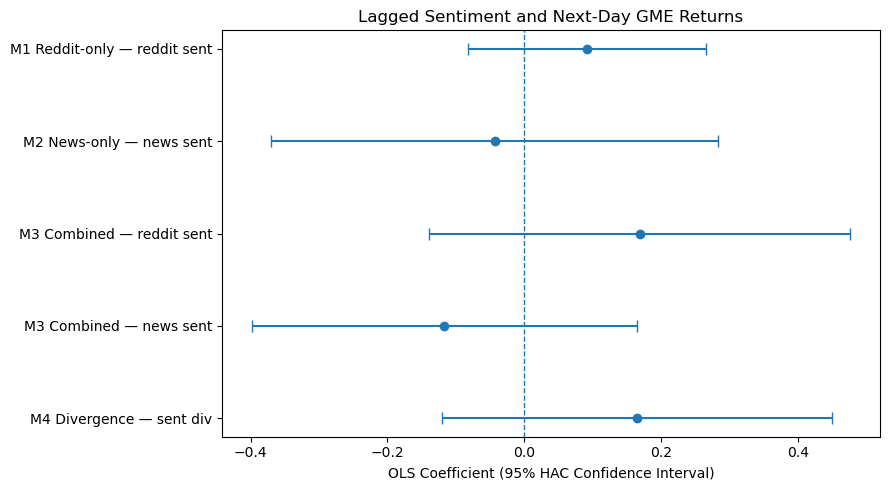

In [40]:
# ---------------------------------------------------------
# 3.9 Plot OLS sentiment coefficients with 95% confidence intervals
# ---------------------------------------------------------

plot_df = coef_df.copy()

plot_df["Label"] = (
    plot_df["Model"] + " — " +
    plot_df["Variable"]
        .str.replace("_lag1", "", regex=False)
        .str.replace("_", " ", regex=False)
)

fig, ax = plt.subplots(figsize=(9, 5))

y_pos = range(len(plot_df))

ax.errorbar(
    plot_df["Coefficient"],
    y_pos,
    xerr=[
        plot_df["Coefficient"] - plot_df["Lower_95"],
        plot_df["Upper_95"] - plot_df["Coefficient"]
    ],
    fmt="o",
    capsize=4
)

# Reference line: no estimated relationship
ax.axvline(0, linewidth=1, linestyle="--")

ax.set_yticks(list(y_pos))
ax.set_yticklabels(plot_df["Label"])

ax.set_xlabel("OLS Coefficient (95% HAC Confidence Interval)")
ax.set_title(
    "Lagged Sentiment and Next-Day GME Returns"
)

ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [41]:
# ---------------------------------------------------------
# 3.10 Granger Causality Tests
# ---------------------------------------------------------

MAX_LAG = 2

granger_specs = {
    "Reddit → GME return": (
        master[["ret_gme", "reddit_weighted_compound"]]
        .dropna()
        .sort_index()
    ),

    "News → GME return": (
        master[["ret_gme", "news_mean_compound"]]
        .dropna()
        .sort_index()
    )
}

print(f"Granger Causality Tests (max lag = {MAX_LAG})\n")

for label, data in granger_specs.items():

    print(label)
    print(f"Observations: {len(data)}")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", FutureWarning)

        with redirect_stdout(io.StringIO()):
            gc = grangercausalitytests(
                data,
                maxlag=MAX_LAG
            )

    for lag in range(1, MAX_LAG + 1):

        f_stat = gc[lag][0]["ssr_ftest"][0]
        p_value = gc[lag][0]["ssr_ftest"][1]

        print(
            f"  Lag {lag}: "
            f"F = {f_stat:.4f}, "
            f"p = {p_value:.4f}"
        )

    print()

Granger Causality Tests (max lag = 2)

Reddit → GME return
Observations: 78
  Lag 1: F = 0.3924, p = 0.5330
  Lag 2: F = 1.4178, p = 0.2490

News → GME return
Observations: 50
  Lag 1: F = 1.9079, p = 0.1739
  Lag 2: F = 0.9204, p = 0.4061



In [42]:
# ------------------------------------------------------------
# 3.11 Define Key GME Events and Assess Estimation-Window Feasibility
# ------------------------------------------------------------

GME_EVENT_DATES = {
    "Pre-squeeze acceleration": "2021-01-13",
    "Major price spike": "2021-01-22",
    "WSB-driven surge": "2021-01-25",
    "Musk 'Gamestonk' attention": "2021-01-26",
    "Robinhood trading restriction": "2021-01-28",
    "Post-restriction selloff": "2021-02-01"
}

# Convert event dates to Timestamp
GME_EVENT_DATES = {
    label: pd.Timestamp(date)
    for label, date in GME_EVENT_DATES.items()
}

# Make sure returns are ordered chronologically
returns = returns.sort_index()

print("Available market-data range:")
print(f"{returns.index.min().date()} → {returns.index.max().date()}")

print("\nTrading days available before each event:")

event_window_check = []

for label, event_date in GME_EVENT_DATES.items():

    # Trading observations strictly before the event
    pre_event = returns.loc[returns.index < event_date]

    n_pre = len(pre_event)

    event_window_check.append({
        "Event": label,
        "Event_Date": event_date.date(),
        "Pre_Event_Trading_Days": n_pre
    })

event_window_check = pd.DataFrame(event_window_check)

display(event_window_check)

Available market-data range:
2020-10-01 → 2021-03-31

Trading days available before each event:


,Event,Event_Date,Pre_Event_Trading_Days
0,Pre-squeeze acceleration,2021-01-13,71
1,Major price spike,2021-01-22,77
2,WSB-driven surge,2021-01-25,78
3,Musk 'Gamestonk' attention,2021-01-26,79
4,Robinhood trading restriction,2021-01-28,81
5,Post-restriction selloff,2021-02-01,83


In [43]:
# ------------------------------------------------------------
# 3.12 Configure Event-Study Windows
# ------------------------------------------------------------

ESTIMATION_WINDOW = (-60, -10)
EVENT_WINDOW = (-3, 5)

print("Event Study Configuration")
print(f"Estimation window: {ESTIMATION_WINDOW}")
print(f"Event window:      {EVENT_WINDOW}")

# Check trading-day coverage around each event
coverage_check = []

for label, event_date in GME_EVENT_DATES.items():

    event_pos = returns.index.get_indexer([event_date])[0]

    if event_pos == -1:
        coverage_check.append({
            "Event": label,
            "Event_Date": event_date.date(),
            "Estimation_Obs": 0,
            "Event_Window_Obs": 0,
            "Status": "Event date not found"
        })
        continue

    est_start = event_pos + ESTIMATION_WINDOW[0]
    est_end = event_pos + ESTIMATION_WINDOW[1]

    evt_start = event_pos + EVENT_WINDOW[0]
    evt_end = event_pos + EVENT_WINDOW[1]

    estimation_obs = max(0, est_end - max(est_start, 0) + 1)
    event_obs = max(
        0,
        min(evt_end, len(returns) - 1) - max(evt_start, 0) + 1
    )

    coverage_check.append({
        "Event": label,
        "Event_Date": event_date.date(),
        "Estimation_Obs": estimation_obs,
        "Event_Window_Obs": event_obs,
        "Status": (
            "OK"
            if estimation_obs == 51 and event_obs == 9
            else "Check coverage"
        )
    })

coverage_check = pd.DataFrame(coverage_check)

display(coverage_check)

Event Study Configuration
Estimation window: (-60, -10)
Event window:      (-3, 5)


,Event,Event_Date,Estimation_Obs,Event_Window_Obs,Status
0,Pre-squeeze acceleration,2021-01-13,51,9,OK
1,Major price spike,2021-01-22,51,9,OK
2,WSB-driven surge,2021-01-25,51,9,OK
3,Musk 'Gamestonk' attention,2021-01-26,51,9,OK
4,Robinhood trading restriction,2021-01-28,51,9,OK
5,Post-restriction selloff,2021-02-01,51,9,OK


In [44]:
# ------------------------------------------------------------
# 3.13 Calculate Abnormal Returns and CAR
# ------------------------------------------------------------

event_study_results = {}
event_summary = []

for label, event_date in GME_EVENT_DATES.items():

    # Locate event in trading-day index
    event_pos = returns.index.get_loc(event_date)

    # --------------------------------------------------------
    # 1. Estimation window: -60 to -10 trading days
    # --------------------------------------------------------
    est_start = event_pos + ESTIMATION_WINDOW[0]
    est_end   = event_pos + ESTIMATION_WINDOW[1]

    estimation_data = returns.iloc[est_start:est_end + 1][
        ["GME", "SPY"]
    ].dropna()

    # Market model:
    # GME return = alpha + beta * SPY return
    X_est = sm.add_constant(estimation_data["SPY"])
    y_est = estimation_data["GME"]

    market_model = sm.OLS(y_est, X_est).fit()

    alpha = market_model.params["const"]
    beta = market_model.params["SPY"]

    # --------------------------------------------------------
    # 2. Event window: -3 to +5 trading days
    # --------------------------------------------------------
    evt_start = event_pos + EVENT_WINDOW[0]
    evt_end   = event_pos + EVENT_WINDOW[1]

    event_data = returns.iloc[evt_start:evt_end + 1][
        ["GME", "SPY"]
    ].copy()

    # Relative trading-day positions
    event_data["Relative_Day"] = range(
        EVENT_WINDOW[0],
        EVENT_WINDOW[1] + 1
    )

    # --------------------------------------------------------
    # 3. Expected and abnormal returns
    # --------------------------------------------------------
    event_data["Expected_Return"] = (
        alpha + beta * event_data["SPY"]
    )

    event_data["Abnormal_Return"] = (
        event_data["GME"] - event_data["Expected_Return"]
    )

    # Cumulative Abnormal Return
    event_data["CAR"] = event_data["Abnormal_Return"].cumsum()

    event_study_results[label] = event_data

    # --------------------------------------------------------
    # 4. Store summary statistics
    # --------------------------------------------------------
    event_day_ar = event_data.loc[
        event_data["Relative_Day"] == 0,
        "Abnormal_Return"
    ].iloc[0]

    final_car = event_data["CAR"].iloc[-1]

    event_summary.append({
        "Event": label,
        "Event_Date": event_date.date(),
        "Alpha": alpha,
        "Beta": beta,
        "Event_Day_AR": event_day_ar,
        "CAR_-3_to_+5": final_car
    })


event_summary = pd.DataFrame(event_summary)

print("Event Study Summary")
display(
    event_summary.round({
        "Alpha": 4,
        "Beta": 4,
        "Event_Day_AR": 4,
        "CAR_-3_to_+5": 4
    })
)

Event Study Summary


,Event,Event_Date,Alpha,Beta,Event_Day_AR,CAR_-3_to_+5
0,Pre-squeeze acceleration,2021-01-13,0.0033,2.3895,0.4439,0.8053
1,Major price spike,2021-01-22,-0.0014,2.6556,0.4234,2.2665
2,WSB-driven surge,2021-01-25,-0.0003,2.3792,0.1574,1.7609
3,Musk 'Gamestonk' attention,2021-01-26,0.0041,2.0692,0.6551,0.8089
4,Robinhood trading restriction,2021-01-28,0.0134,2.0873,-0.6163,-0.3332
5,Post-restriction selloff,2021-02-01,0.0192,1.6166,-0.4136,-1.1036


In [45]:
# ------------------------------------------------------------
# 3.14 Statistical Significance of CAR
# ------------------------------------------------------------

event_sig_results = []

for label, event_date in GME_EVENT_DATES.items():

    # Locate event in actual trading-day index
    event_pos = returns.index.get_loc(event_date)

    # --------------------------------------------------------
    # 1. Estimation window: -60 to -10 trading days
    # --------------------------------------------------------
    est_start = event_pos + ESTIMATION_WINDOW[0]
    est_end   = event_pos + ESTIMATION_WINDOW[1]

    estimation_data = returns.iloc[
        est_start:est_end + 1
    ][["GME", "SPY"]].dropna()

    # Market model
    X_est = sm.add_constant(estimation_data["SPY"])
    y_est = estimation_data["GME"]

    market_model = sm.OLS(y_est, X_est).fit()

    alpha = market_model.params["const"]
    beta  = market_model.params["SPY"]

    # Residual volatility from estimation period
    sigma_e = market_model.resid.std(ddof=2)

    # --------------------------------------------------------
    # 2. Event window: -3 to +5 trading days
    # --------------------------------------------------------
    evt_start = event_pos + EVENT_WINDOW[0]
    evt_end   = event_pos + EVENT_WINDOW[1]

    event_data = returns.iloc[
        evt_start:evt_end + 1
    ][["GME", "SPY"]].copy()

    # Expected return
    event_data["Expected_Return"] = (
        alpha + beta * event_data["SPY"]
    )

    # Abnormal return
    event_data["Abnormal_Return"] = (
        event_data["GME"] -
        event_data["Expected_Return"]
    )

    # --------------------------------------------------------
    # 3. CAR significance
    # --------------------------------------------------------
    car = event_data["Abnormal_Return"].sum()

    n_event = len(event_data)

    car_se = sigma_e * np.sqrt(n_event)

    z_stat = car / car_se

    p_value = 2 * (1 - norm.cdf(abs(z_stat)))

    event_sig_results.append({
        "Event": label,
        "Event_Date": event_date.date(),
        "N_Event_Days": n_event,
        "CAR": car,
        "CAR_SE": car_se,
        "Z_stat": z_stat,
        "P_value": p_value,
        "Significant_5pct": p_value < 0.05
    })


event_sig_df = pd.DataFrame(event_sig_results)

display_df = event_sig_df.copy()

for col in ["CAR", "CAR_SE", "Z_stat", "P_value"]:
    display_df[col] = display_df[col].round(4)

print("Event Study — CAR Significance Tests")
print(
    f"Event window: "
    f"[{EVENT_WINDOW[0]}, +{EVENT_WINDOW[1]}]"
)
print("H0: CAR = 0\n")

display(display_df)

Event Study — CAR Significance Tests
Event window: [-3, +5]
H0: CAR = 0



,Event,Event_Date,N_Event_Days,CAR,CAR_SE,Z_stat,P_value,Significant_5pct
0,Pre-squeeze acceleration,2021-01-13,9,0.8053,0.1955,4.1183,0.0000,True
1,Major price spike,2021-01-22,9,2.2665,0.1948,11.6341,0.0000,True
2,WSB-driven surge,2021-01-25,9,1.7609,0.1936,9.0938,0.0000,True
3,Musk 'Gamestonk' attention,2021-01-26,9,0.8089,0.2006,4.0329,0.0001,True
4,Robinhood trading restriction,2021-01-28,9,-0.3332,0.2746,-1.2135,0.2250,False
5,Post-restriction selloff,2021-02-01,9,-1.1036,0.2924,-3.7740,0.0002,True


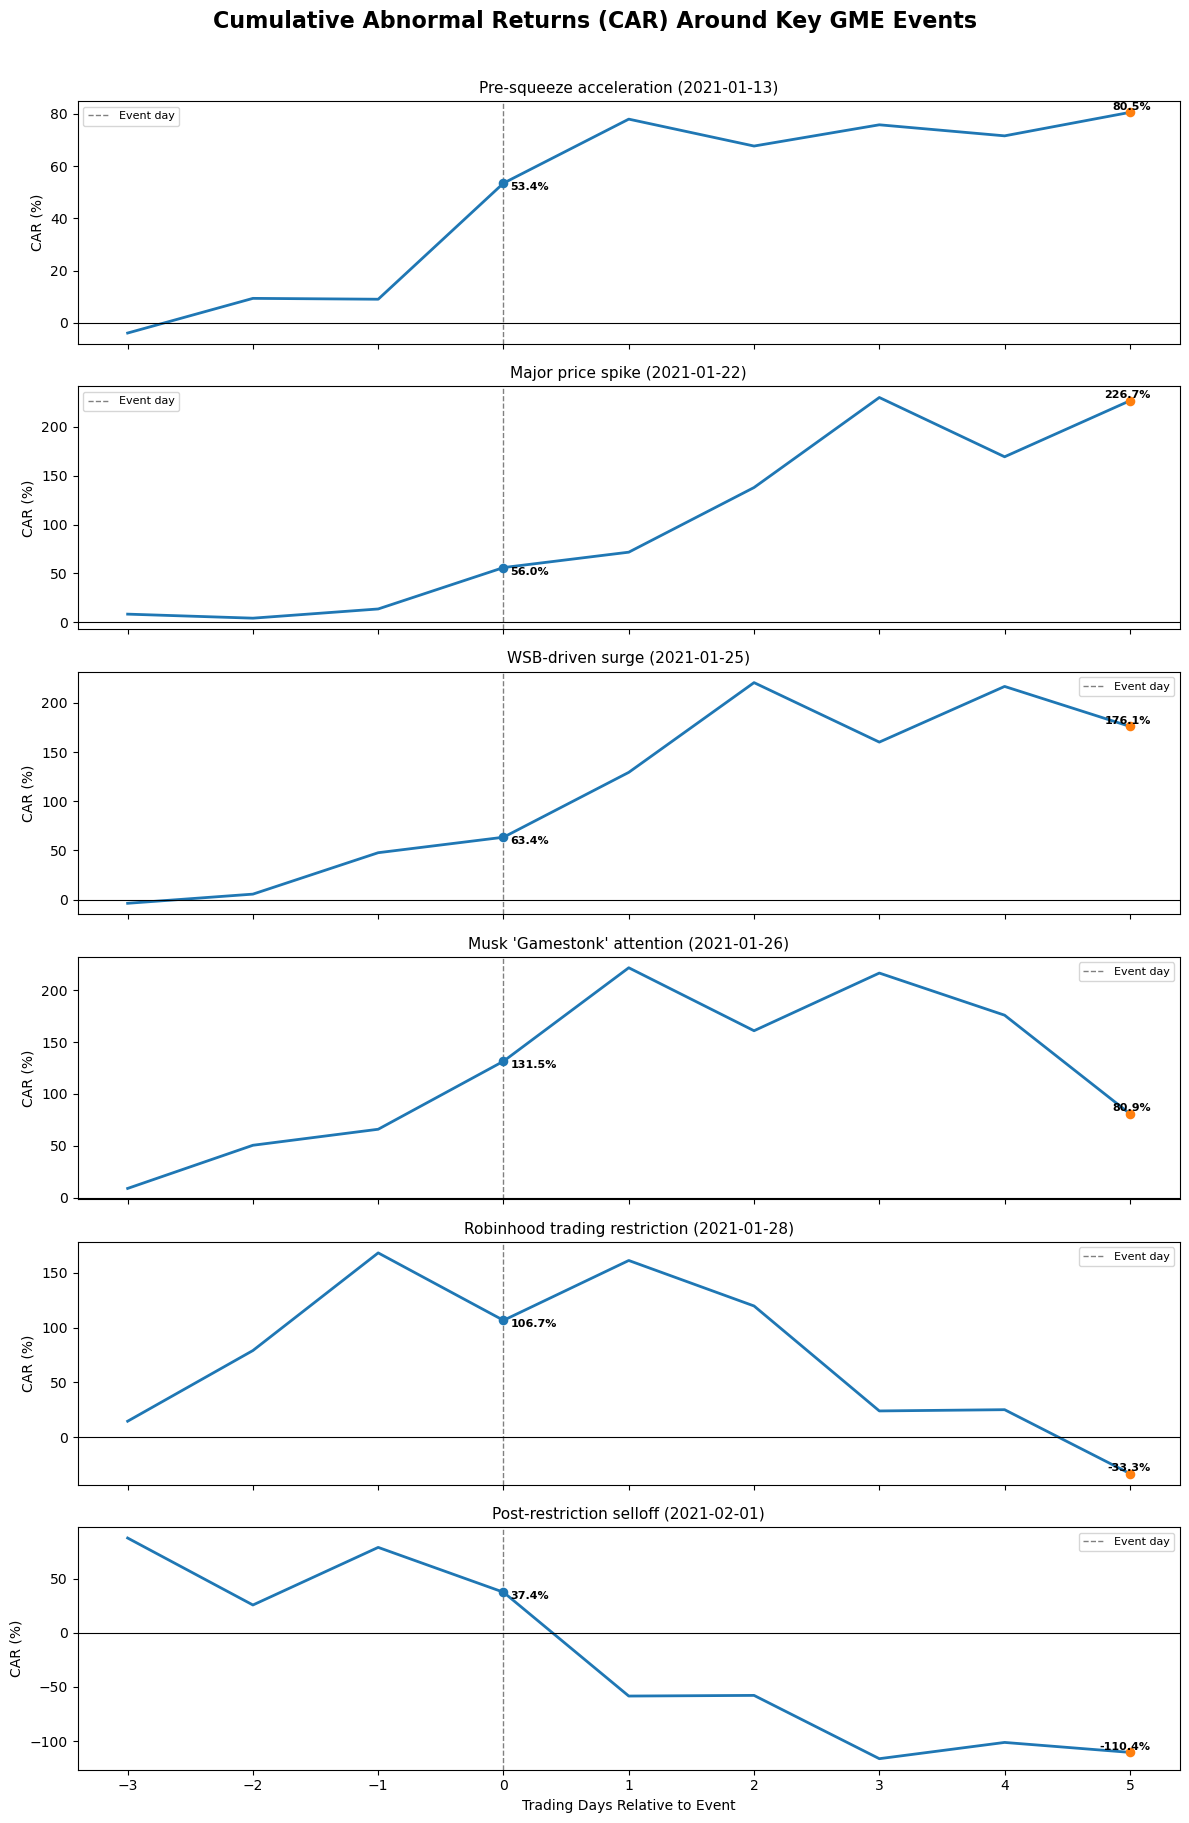

In [46]:
# ------------------------------------------------------------
# 3.15 Visualize Event Study Results
# ------------------------------------------------------------

n_events = len(event_study_results)

fig, axes = plt.subplots(
    n_events, 1,
    figsize=(12, 3 * n_events),
    sharex=True
)

fig.suptitle(
    "Cumulative Abnormal Returns (CAR) Around Key GME Events",
    fontsize=16,
    fontweight="bold",
    y=1.01
)

for ax, (label, event_data) in zip(axes, event_study_results.items()):
    event_date = GME_EVENT_DATES[label]

    # Convert CAR to percentage for visualization
    car_pct = event_data["CAR"] * 100

    # CAR line
    ax.plot(
        event_data["Relative_Day"],
        car_pct,
        linewidth=2
    )

    # Highlight Event Day (0) and Final Day (+5)
    for day in [0, EVENT_WINDOW[1]]:

        row = event_data.loc[
            event_data["Relative_Day"] == day
        ]

        if not row.empty:
            x = row["Relative_Day"].iloc[0]
            y = row["CAR"].iloc[0] * 100

            ax.scatter(
                x,
                y,
                s=35,
                zorder=3
            )

            # Keep final-day label inside the plot
            if day == EVENT_WINDOW[1]:
                xytext = (15, 2)
                ha = "right"
            else:
                xytext = (5, -5)
                ha = "left"

            ax.annotate(
                f"{y:.1f}%",
                xy=(x, y),
                xytext=xytext,
                textcoords="offset points",
                fontsize=8,
                fontweight="bold",
                ha=ha
            )

    # Event-day reference line
    ax.axvline(
        x=0,
        color="gray",
        linestyle="--",
        linewidth=1,
        label="Event day"
    )

    # Zero-CAR reference line
    ax.axhline(
        y=0,
        color="black",
        linewidth=0.8
    )

    ax.set_title(
        f"{label} ({event_date.date()})",
        fontsize=11
    )

    ax.set_ylabel("CAR (%)")
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Trading Days Relative to Event")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig_event_study.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 4 - Statistical Significance Tests

In [47]:
# ------------------------------------------------------------
# 4.1 Mann-Whitney U Test
# Reddit vs News Sentiment Distributions
# ------------------------------------------------------------

# Remove missing sentiment values
reddit_sentiment = reddit["vader_compound"].dropna()
news_sentiment = news["vader_compound"].dropna()

# Two-sided Mann-Whitney U test
u_stat, u_pval = mannwhitneyu(
    reddit_sentiment,
    news_sentiment,
    alternative="two-sided"
)

print("Mann-Whitney U Test")
print("Reddit vs News VADER Compound Sentiment")
print()
print(f"Reddit observations: {len(reddit_sentiment):,}")
print(f"News observations:   {len(news_sentiment):,}")
print(f"U statistic: {u_stat:.0f}")
print(f"P-value:     {u_pval:.6f}")

if u_pval < 0.05:
    print("\nResult: Significant difference at alpha = 0.05")
else:
    print("\nResult: No significant difference at alpha = 0.05")

Mann-Whitney U Test
Reddit vs News VADER Compound Sentiment

Reddit observations: 2,361
News observations:   1,334
U statistic: 2146344
P-value:     0.000000

Result: Significant difference at alpha = 0.05


In [48]:
# ------------------------------------------------------------
# 4.2 Welch's Independent t-test
# Reddit vs News Mean Sentiment
# ------------------------------------------------------------

t_stat, t_pval = ttest_ind(
    reddit_sentiment,
    news_sentiment,
    equal_var=False
)

print("Welch's Independent t-test")
print("Reddit vs News Mean VADER Compound Sentiment")
print()
print(f"Reddit mean: {reddit_sentiment.mean():.4f}")
print(f"News mean:   {news_sentiment.mean():.4f}")
print(f"T statistic: {t_stat:.4f}")
print(f"P-value:     {t_pval:.6f}")

if t_pval < 0.05:
    print("\nResult: Significant difference in mean sentiment at alpha = 0.05")
else:
    print("\nResult: No significant difference in mean sentiment at alpha = 0.05")

Welch's Independent t-test
Reddit vs News Mean VADER Compound Sentiment

Reddit mean: 0.3054
News mean:   0.0107
T statistic: 19.2415
P-value:     0.000000

Result: Significant difference in mean sentiment at alpha = 0.05


In [49]:
# ------------------------------------------------------------
# 4.3 Effect Size of Sentiment Difference
# Cohen's d: Reddit vs News Sentiment
# ------------------------------------------------------------

# Sample sizes
n_reddit = len(reddit_sentiment)
n_news = len(news_sentiment)

# Sample standard deviations
sd_reddit = reddit_sentiment.std(ddof=1)
sd_news = news_sentiment.std(ddof=1)

# Pooled standard deviation
pooled_sd = np.sqrt(
    (
        (n_reddit - 1) * sd_reddit**2
        + (n_news - 1) * sd_news**2
    )
    / (n_reddit + n_news - 2)
)

# Cohen's d
cohens_d = (
    reddit_sentiment.mean()
    - news_sentiment.mean()
) / pooled_sd

print("Effect Size of Sentiment Difference")
print("Reddit vs News VADER Compound Sentiment")
print()
print(f"Reddit mean: {reddit_sentiment.mean():.4f}")
print(f"News mean:   {news_sentiment.mean():.4f}")
print(f"Cohen's d:   {cohens_d:.4f}")

# Conventional interpretation
abs_d = abs(cohens_d)

if abs_d < 0.2:
    magnitude = "negligible"
elif abs_d < 0.5:
    magnitude = "small"
elif abs_d < 0.8:
    magnitude = "medium"
else:
    magnitude = "large"

print(f"Magnitude:   {magnitude}")

Effect Size of Sentiment Difference
Reddit vs News VADER Compound Sentiment

Reddit mean: 0.3054
News mean:   0.0107
Cohen's d:   0.5641
Magnitude:   medium


In [ ]:
# ------------------------------------------------------------
# 4.4 Pearson Correlation
# Daily Sentiment vs Same-Day GME Return
# ------------------------------------------------------------

# Reddit
reddit_corr_data = master[
    ["reddit_weighted_compound", "ret_gme"]
].dropna()

r_reddit, p_reddit = pearsonr(
    reddit_corr_data["reddit_weighted_compound"],
    reddit_corr_data["ret_gme"]
)

# News
news_corr_data = master[
    ["news_mean_compound", "ret_gme"]
].dropna()

r_news, p_news = pearsonr(
    news_corr_data["news_mean_compound"],
    news_corr_data["ret_gme"]
)

print("Pearson Correlation")
print("Daily Sentiment vs Same-Day GME Return")
print()

print("Reddit")
print(f"Observations: {len(reddit_corr_data)}")
print(f"r:           {r_reddit:.4f}")
print(f"P-value:     {p_reddit:.6f}")

print("\nNews")
print(f"Observations: {len(news_corr_data)}")
print(f"r:           {r_news:.4f}")
print(f"P-value:     {p_news:.6f}")

Pearson Correlation
Daily Sentiment vs Same-Day GME Return

Reddit
Observations: 78
r:           0.0232
P-value:     0.839915

News
Observations: 50
r:           -0.1132
P-value:     0.433896


In [ ]:
# ------------------------------------------------------------
# 4.5 Spearman Rank Correlation
# Daily Sentiment vs Same-Day GME Return
# ------------------------------------------------------------

# Reddit
rho_reddit, p_rho_reddit = spearmanr(
    reddit_corr_data["reddit_weighted_compound"],
    reddit_corr_data["ret_gme"]
)

# News
rho_news, p_rho_news = spearmanr(
    news_corr_data["news_mean_compound"],
    news_corr_data["ret_gme"]
)

print("Spearman Rank Correlation")
print("Daily Sentiment vs Same-Day GME Return")
print()

print("Reddit")
print(f"Observations: {len(reddit_corr_data)}")
print(f"rho:         {rho_reddit:.4f}")
print(f"P-value:     {p_rho_reddit:.6f}")

print("\nNews")
print(f"Observations: {len(news_corr_data)}")
print(f"rho:         {rho_news:.4f}")
print(f"P-value:     {p_rho_news:.6f}")

Spearman Rank Correlation
Daily Sentiment vs Same-Day GME Return

Reddit
Observations: 78
rho:         -0.0693
P-value:     0.546449

News
Observations: 50
rho:         -0.1040
P-value:     0.472464


In [ ]:
# ------------------------------------------------------------
# 4.6 Chi-Square Test
# Reddit Bullish Sentiment vs GME Up Day
# ------------------------------------------------------------

from scipy.stats import chi2_contingency

chi_data = master[
    ["reddit_weighted_compound", "ret_gme"]
].dropna().copy()

# Binary indicators
chi_data["reddit_bullish"] = (
    chi_data["reddit_weighted_compound"] > 0
).astype(int)

chi_data["gme_up"] = (
    chi_data["ret_gme"] > 0
).astype(int)

# Contingency table
contingency_table = pd.crosstab(
    chi_data["reddit_bullish"],
    chi_data["gme_up"]
)

chi2, chi_pval, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-Square Test of Independence")
print("Reddit Bullish Sentiment vs Same-Day GME Direction")
print()

print("Observed contingency table:")
display(contingency_table)

print(f"Observations: {len(chi_data)}")
print(f"Chi-square:   {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value:      {chi_pval:.6f}")

if chi_pval < 0.05:
    print("\nResult: Significant association at alpha = 0.05")
else:
    print("\nResult: No significant association at alpha = 0.05")

Chi-Square Test of Independence
Reddit Bullish Sentiment vs Same-Day GME Direction

Observed contingency table:


gme_up,0,1
reddit_bullish,,
0,8,6
1,31,33


Observations: 78
Chi-square:   0.0871
Degrees of freedom: 1
P-value:      0.767957

Result: No significant association at alpha = 0.05


In [55]:
# ------------------------------------------------------------
# 4.7 Statistical Test Summary
# ------------------------------------------------------------

statistical_summary = pd.DataFrame([
    {
        "Test": "Mann-Whitney U",
        "Comparison": "Reddit vs News sentiment distribution",
        "Statistic": u_stat,
        "P_Value": u_pval,
        "Significant_5pct": u_pval < 0.05
    },
    {
        "Test": "Welch's t-test",
        "Comparison": "Reddit vs News mean sentiment",
        "Statistic": t_stat,
        "P_Value": t_pval,
        "Significant_5pct": t_pval < 0.05
    },
    {
        "Test": "Pearson (Reddit)",
        "Comparison": "Sentiment vs same-day GME return",
        "Statistic": r_reddit,
        "P_Value": p_reddit,
        "Significant_5pct": p_reddit < 0.05
    },
    {
        "Test": "Pearson (News)",
        "Comparison": "Sentiment vs same-day GME return",
        "Statistic": r_news,
        "P_Value": p_news,
        "Significant_5pct": p_news < 0.05
    },
    {
        "Test": "Spearman (Reddit)",
        "Comparison": "Sentiment vs same-day GME return",
        "Statistic": rho_reddit,
        "P_Value": p_rho_reddit,
        "Significant_5pct": p_rho_reddit < 0.05
    },
    {
        "Test": "Spearman (News)",
        "Comparison": "Sentiment vs same-day GME return",
        "Statistic": rho_news,
        "P_Value": p_rho_news,
        "Significant_5pct": p_rho_news < 0.05
    },
    {
        "Test": "Chi-square",
        "Comparison": "Reddit bullish sentiment vs same-day GME direction",
        "Statistic": chi2,
        "P_Value": chi_pval,
        "Significant_5pct": chi_pval < 0.05
    }
])

# Format summary for display
summary_display = statistical_summary.copy()

summary_display["Statistic"] = summary_display["Statistic"].map(
    lambda x: f"{x:.4f}"
)

summary_display["P_Value"] = summary_display["P_Value"].map(
    lambda x: "<0.000001" if x < 0.000001 else f"{x:.6f}"
)

print("Statistical Test Summary")
print("Alpha = 0.05")
print()

display(summary_display)

Statistical Test Summary
Alpha = 0.05



,Test,Comparison,Statistic,P_Value,Significant_5pct
0,Mann-Whitney U,Reddit vs News sentiment distribution,2146343.5000,<0.000001,True
1,Welch's t-test,Reddit vs News mean sentiment,19.2415,<0.000001,True
2,Pearson (Reddit),Sentiment vs same-day GME return,0.0232,0.839915,False
3,Pearson (News),Sentiment vs same-day GME return,-0.1132,0.433896,False
4,Spearman (Reddit),Sentiment vs same-day GME return,-0.0693,0.546449,False
5,Spearman (News),Sentiment vs same-day GME return,-0.1040,0.472464,False
6,Chi-square,Reddit bullish sentiment vs same-day GME direc...,0.0871,0.767957,False


## 5 - Key Findings and Conclusions

The revised analysis produced three broad findings.

### Key Findings

**5.1 Reddit and institutional news reflected different information environments**

Reddit and institutional news differed both in tone and in the themes emphasized during the GameStop episode.

Reddit sentiment was substantially more positive than institutional-news sentiment. Mean VADER compound sentiment was 0.3054 for Reddit compared with 0.0107 for news. Reddit posts were classified as positive 62.35% of the time, while institutional-news headlines were more concentrated around neutral sentiment, with 43.70% classified as neutral. The difference between the two sources was statistically significant under both the Mann-Whitney U test and Welch's t-test (both p < 0.000001), while Cohen's d = 0.5641 indicates a medium effect size.

The WallStreetBets-specific lexicon also had a meaningful effect on Reddit sentiment measurement. Relative to standard VADER, the augmented lexicon changed the compound sentiment score for 74.5% of Reddit posts and changed the positive, neutral, or negative classification for 18.6% of posts. Mean Reddit compound sentiment increased from 0.2650 under standard VADER to 0.3054 after applying the WSB-specific lexicon.

Topic modeling provided a second view of how the two information sources differed. Reddit topics centered on retail trading language and holding behavior; short squeezes, options, and short positions; Robinhood, Citadel, and trading restrictions; market and earnings discussions; and GameStop's company fundamentals, including Ryan Cohen, the board, digital transformation, and revenue. Institutional-news topics focused more heavily on short-squeeze coverage and short sellers; Wall Street, hedge funds, and retail investors; broader meme-stock coverage involving AMC, BlackBerry, and silver; Robinhood and media coverage; and the broader GameStop trading saga.

Taken together, the sentiment and topic results suggest that Reddit and institutional news were capturing different aspects of the same market episode. Reddit reflected a more positive, community-driven and trading-oriented discussion, while institutional news presented a broader and more neutral market narrative.

**5.2 These differences did not translate into a reliable daily relationship with GME returns**

Despite the clear difference in sentiment between the two sources, neither source showed a statistically significant same-day relationship with GME returns.

For Reddit, the Pearson correlation between daily engagement-weighted sentiment and same-day GME return was r = 0.0232 (p = 0.8399), while the Spearman correlation was rho = -0.0693 (p = 0.5464). For institutional news, the corresponding Pearson correlation was r = -0.1132 (p = 0.4339) and the Spearman correlation was rho = -0.1040 (p = 0.4725). A chi-square test also found no significant association between bullish Reddit sentiment and whether GME had a positive same-day return (chi-square = 0.0871, p = 0.7680).

Lagged sentiment produced a similar result. None of the four OLS specifications explaining next-day GME returns was statistically significant. R-squared values ranged from 0.0452 to 0.1054, and none of the Reddit, news, or sentiment-divergence coefficients reached conventional significance levels. The smallest sentiment-related p-value was 0.2572 for the sentiment-divergence specification.

The much lower R-squared values in the expanded analysis also contrast with the approximately 0.73-0.82 values obtained in the earlier version of the project using only about 10 overlapping observations. The disappearance of the strong fit after substantially increasing the usable sample suggests that the earlier result was likely influenced by small-sample overfitting rather than representing a stable sentiment-return relationship.

**5.3 Sentiment also showed limited out-of-sample predictive value**

The predictive classification models did not provide convincing evidence that either sentiment source could reliably predict next-day GME direction.

Across five time-series cross-validation folds, mean accuracy ranged from 0.400 to 0.600 and mean ROC-AUC ranged from 0.436 to 0.613. The best average result was obtained by the news-only Random Forest, with mean accuracy of 0.600 and mean ROC-AUC of 0.613, but performance varied substantially across folds, with a ROC-AUC standard deviation of 0.387. The combined Reddit-and-news models did not improve consistently over the source-specific models.

Granger causality tests led to the same conclusion. Reddit sentiment did not significantly predict GME returns at either a one-day lag (p = 0.5330) or a two-day lag (p = 0.2490). Institutional-news sentiment was also non-significant at one-day (p = 0.1739) and two-day (p = 0.4061) lags.

These results suggest that, at the daily frequency used in this project, neither Reddit nor institutional-news sentiment provides a stable short-term predictive signal for GME returns.

**5.4 Major GME events were nevertheless associated with unusually large abnormal returns**

The absence of a stable daily sentiment-return relationship does not mean that the GameStop episode lacked extraordinary market movements.

The event study compared GME returns with expected returns estimated from its pre-event relationship with SPY over a nine-trading-day event window from three days before to five days after each selected event. Cumulative abnormal returns were statistically significant for five of the six events.

The strongest positive cumulative abnormal return occurred around the January 22 major price spike (CAR = 2.2665), followed by the January 25 WSB-driven surge (CAR = 1.7609). Positive and statistically significant CARs were also observed around the January 13 pre-squeeze acceleration and January 26 Musk "Gamestonk" attention events. The February 1 post-restriction selloff produced a large negative CAR of -1.1036 (p = 0.0002). The January 28 Robinhood trading-restriction window was the only event without statistically significant CAR (CAR = -0.3332, p = 0.2250).

These findings show that GME experienced unusually large market-adjusted price movements around several important dates. However, the event study does not establish that Reddit or institutional-news sentiment caused those movements, particularly because several event windows overlap and the dates were selected from the known GameStop squeeze narrative.

### Conclusion

The revised analysis does not support the original expectation that institutional-news sentiment has stronger explanatory or predictive power for short-term GME returns than Reddit sentiment. Instead, the clearest result is the distinction between the information environment surrounding the GameStop episode and the ability of that information to predict daily market movements.

Reddit and institutional news differed meaningfully in both sentiment and thematic emphasis. Reddit discourse was substantially more positive and focused heavily on retail trading behavior, short squeezes, trading restrictions, and GameStop-specific company developments. Institutional news presented a more neutral and broader market-oriented account of the same episode. However, these differences did not translate into statistically reliable same-day correlations, significant lagged OLS relationships, stable out-of-sample predictive performance, or Granger-causal relationships with daily GME returns.

At the same time, the event study confirms that GME experienced unusually large abnormal returns around several key squeeze-period events. The combined evidence therefore suggests that the GameStop episode cannot be reduced to a simple relationship in which more positive Reddit or news sentiment consistently leads to higher short-term returns. The information environment was clearly different across the two sources, but daily sentiment alone was not sufficient to explain or predict the stock's extreme price movements.